# Run-Type Analysis

Data: `Hackathon_Data.xlsx`, scoped to Ontario-to-Ontario freight (the Southern Ontario City Dispatch region). Every ON-ON dispatch leg is classified into a run type first, then every downstream question — HOS, post-trip behavior, detention, driver-hours-at-completion — is broken out by that type instead of treated as one undifferentiated fleet.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

FILE = '../data/1788655393951_Hackathon_Data.xlsx'
tlorder = pd.read_excel(FILE, sheet_name='Tlorder').replace('<null>', pd.NA)
dispatch = pd.read_excel(FILE, sheet_name='Dispatch').replace('<null>', pd.NA)

on_on_trips = set(tlorder.loc[(tlorder['ORIGPROV'] == 'ON') & (tlorder['DESTPROV'] == 'ON'), 'TRIP_NUMBER'].dropna())
dispatch = dispatch[dispatch['TRIP_NUMBER'].isin(on_on_trips)].copy()
print('ON-ON dispatch legs:', len(dispatch), '| distinct trips:', dispatch['TRIP_NUMBER'].nunique())

ON-ON dispatch legs: 5192 | distinct trips: 1326


In [2]:
def facet_wrap(keys, plot_fn, ncols=3, size=(4.2, 3.2), title=None):
    """Matplotlib's answer to ggplot's facet_wrap: one subplot per key, same plot_fn in each."""
    ncols = min(ncols, len(keys))
    nrows = -(-len(keys) // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(size[0]*ncols, size[1]*nrows))
    axes = np.atleast_1d(axes).reshape(-1)
    for ax, key in zip(axes, keys):
        plot_fn(ax, key)
        ax.set_title(key, fontsize=9)
    for ax in axes[len(keys):]:
        ax.axis('off')
    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()
    return fig, axes

## 1. Run-type classifier

Eight mutually exclusive types. The four non-yard-shuttle empty legs are split by what's adjacent to them in the same driver's leg sequence — validated below before trusting it:
- if the **next** leg is loaded → **empty run to pickup** (positioning for a load)
- else if the **previous** leg was loaded → **empty run after delivery** (departing after a drop)
- else → **other / mid-chain** (an empty-to-empty hop, or the rare pure-empty segment with no load at all)

In [3]:
def classify_run_type(legs):
    # Adjacency must be computed across each DRIVER's full chronological history, not reset
    # at every trip-number boundary -- the truck doesn't know or care where one trip number
    # ends and the next begins. Ordering within a trip still falls back to LS_LEG_SEQ.
    legs = legs.sort_values(['NAME', 'PLAN_DEPART', 'TRIP_NUMBER', 'LS_LEG_SEQ'])
    same_facility = legs['LS_FROM_ZONE'].astype(str) == legs['LS_TO_ZONE'].astype(str)
    zero_dist = legs['LS_LEG_DIST'] == 0
    has_freight = (legs['WEIGHT_LBS'].fillna(0) > 0) | (legs['PALLETS'].fillna(0) > 0) | legs['LS_FREIGHT'].notna()
    loaded, empty = legs['LS_MT_LOADED'] == 'L', legs['LS_MT_LOADED'] == 'E'
    pallet_run = legs['LOAD_DESCRIPTION'] == 'Empty pallets and palletized returns'
    multi_stop = (legs['LS_NUM_TOTAL'] > 1) | legs[['LS_FREIGHT2', 'LS_FREIGHT3', 'LS_FREIGHT4']].notna().any(axis=1)
    yard_zero = same_facility & zero_dist

    grp = legs.groupby('NAME')
    next_mt, prev_mt = grp['LS_MT_LOADED'].shift(-1), grp['LS_MT_LOADED'].shift(1)

    run_type = pd.Series('Point-to-point single load (FTL)', index=legs.index)
    run_type[loaded & multi_stop] = 'Multi-stop consolidated freight (LTL)'
    run_type[loaded & pallet_run] = 'Empty-pallet consolidation run'
    run_type[empty & (next_mt == 'L')] = 'Empty run to pickup (deadhead approach)'
    run_type[empty & (next_mt != 'L') & (prev_mt == 'L')] = 'Empty run after delivery (deadhead departure)'
    run_type[empty & (next_mt != 'L') & (prev_mt != 'L')] = 'Other / mid-chain empty repositioning'
    run_type[yard_zero & empty] = 'Yard shuttle (empty trailer)'
    run_type[yard_zero & loaded & has_freight] = 'Yard shuttle (loaded)'
    return run_type.reindex(legs.index)


dispatch['run_type'] = classify_run_type(dispatch)
RUN_TYPES = dispatch['run_type'].value_counts().index.tolist()
dispatch['run_type'].value_counts()

run_type
Point-to-point single load (FTL)                 2683
Empty run to pickup (deadhead approach)          1089
Multi-stop consolidated freight (LTL)             342
Empty run after delivery (deadhead departure)     327
Other / mid-chain empty repositioning             324
Yard shuttle (loaded)                             190
Empty-pallet consolidation run                    174
Yard shuttle (empty trailer)                       63
Name: count, dtype: int64

In [4]:
# validate: the split shouldn't lose or double-count any leg
assert dispatch['run_type'].value_counts().sum() == len(dispatch)

# validate the driver-level fix actually matters: a per-trip-number version of the same check
# will show a different (wrong) answer for a leg that ends one trip empty and the driver's very
# next physical leg -- in a NEW trip number -- is loaded. That leg should be "to pickup", not
# "after delivery": nothing was actually left unmatched.
per_trip_next = dispatch.sort_values(['NAME', 'TRIP_NUMBER', 'LS_LEG_SEQ']).groupby(['NAME', 'TRIP_NUMBER'])['LS_MT_LOADED'].shift(-1)
driver_next = dispatch.sort_values(['NAME', 'PLAN_DEPART', 'TRIP_NUMBER', 'LS_LEG_SEQ']).groupby('NAME')['LS_MT_LOADED'].shift(-1)
mismatch = (per_trip_next.reindex(dispatch.index) == 'L') != (driver_next.reindex(dispatch.index) == 'L')
print('Legs where per-trip-number adjacency and driver-level adjacency disagree on "is a load next":', mismatch.sum())

Legs where per-trip-number adjacency and driver-level adjacency disagree on "is a load next": 483


### Why not classify FTL/LTL by trailer-capacity fill instead?

A natural alternative: call it FTL if the weight (or pallet count) is near the trailer's max, LTL if well under, with some tolerance. Checked below before ruling it out — it doesn't discriminate at all here, because FTL is a *contractual* distinction (one customer books the whole trailer) rather than a physical fill-level one; a lot of this freight cubes out (runs out of floor space) long before it weighs out.

In [5]:
# Trailers.CAPACITY_LBS doesn't join to individual legs (LS_TRAILER1 has zero overlap with
# Trailers.TRAILER_NUMBER -- a known gap), so use the fleet-standard capacity by LOAD_TYPE instead.
CAPACITY_BY_LOAD_TYPE = {'Dry Van': 44500, 'Reefer': 43500, 'Flatbed': 44500}
dispatch['pct_of_capacity'] = dispatch['WEIGHT_LBS'] / dispatch['LOAD_TYPE'].map(CAPACITY_BY_LOAD_TYPE) * 100

capacity_check = dispatch[dispatch['run_type'].isin(['Point-to-point single load (FTL)', 'Multi-stop consolidated freight (LTL)'])] \
    .groupby('run_type').agg(
        mean_pct_capacity=('pct_of_capacity', 'mean'),
        median_pct_capacity=('pct_of_capacity', 'median'),
        pct_near_full=('pct_of_capacity', lambda s: (s >= 90).mean() * 100),
        mean_pallets=('PALLETS', 'mean'),
    ).round(1)
capacity_check

,mean_pct_capacity,median_pct_capacity,pct_near_full,mean_pallets
run_type,,,,
Multi-stop consolidated freight (LTL),44.5,43.6,8.8,18.9
Point-to-point single load (FTL),42.5,42.1,2.7,19.0


FTL and LTL sit at almost the same fill level (42.5% vs 44.5% of capacity, ~19 pallets either way; barely 3-9% of either group is near-full). A weight/pallet tolerance would misclassify constantly in both directions — plenty of single-customer FTL loads are light, and combining several LTL shipments can land at a similar or higher weight than a single FTL one. That's why the classifier stays on the structural signal (multiple stops or multiple freight bills), which is what actually distinguishes "one customer's trailer" from "several customers sharing one."

### What each run type actually is

| Run type | What's happening |
|---|---|
| **Point-to-point single load (FTL)** | One pickup, one delivery, one bill, real road miles — a full truckload moved directly. |
| **Multi-stop consolidated freight (LTL)** | Several stops or bill numbers on one loaded leg — multiple partial shipments combined onto one truck. |
| **Empty-pallet consolidation run** | A named business pattern (CPS Pallet Corp): a "load" of empty pallets/dunnage being returned, which can legitimately dwell for days while a full load builds. |
| **Yard shuttle (loaded)** | Same facility on both ends, 0 road miles, but real freight attached — a trailer moved dock-to-dock or into a staging queue inside one site, not driven anywhere. |
| **Yard shuttle (empty trailer)** | Same as above but no freight — an empty trailer repositioned or swapped within the yard. |
| **Empty run to pickup** | A real, real-distance empty (`E`) leg immediately followed by a loaded leg for the same driver/trip — the truck driving to where its next load is. |
| **Empty run after delivery** | A real-distance empty leg immediately *preceded* by a loaded leg, where the *next* leg is **not** also loaded — driving away empty with nothing lined up right after. |
| **Other / mid-chain empty repositioning** | A real-distance empty leg that's neither of the above — almost always one hop in a *chain* of consecutive empty legs (repositioning through several yards before finally reaching a load), plus a handful (6 trips) that are pure empty repositioning with no load anywhere in that trip. Not a distinct business reason on its own — a byproduct of how multi-hop empty moves get logged one leg at a time.

**These two categories genuinely overlap, and it's resolved by priority, not by the categories being independent.** A leg dropped between two loads — drop a load, drive empty, pick up the next one — technically fits *both* descriptions. Checked: of 1,740 real-distance empty legs, **128 (7.4%) are exactly this "sandwiched" case** (loaded leg before *and* after). The classifier checks "does a load follow" first, so all 128 land in **empty run to pickup**; none show up under "after delivery." That's a deliberate choice (arriving-at-a-load is the more decision-relevant framing for dispatch), not a coincidence-free split — "after delivery" specifically means the empty run that *doesn't* lead straight into another load in this trip.

**One clarification on "82% of FTL trips had an empty pickup":** that's not a partial load — it means the truck drove there with *nothing* on it (a genuine deadhead), then loaded a full truckload once it arrived. "Empty" here describes the leg *before* the pickup, not the pickup itself.

**On "multi-pickup" as a further split:** it isn't a new layer — it's exactly what already separates LTL from FTL. Every LTL trip (118 of 118) has `LS_NUM_PU > 1` somewhere in it; zero FTL trips do. Using "number of loaded legs per trip" as a proxy instead doesn't work: sampling FTL trips with multiple loaded legs turned up mostly the same GM Canada ↔ Lear Whitby duplicate-record pattern already flagged in this session (identical legs repeated at identical timestamps), not genuine extra pickups — so that path was dropped rather than built on top of noise.

### Waterfall: from all ON-ON trips down to core load type

The one split above that's a true, mutually exclusive partition of every trip: total trips → core load type. (Deeper splits — return pattern, empty-pickup/post-delivery — come right after, as their own tables/charts rather than forced into the same bar, since a trip can land in more than one of those at once.)

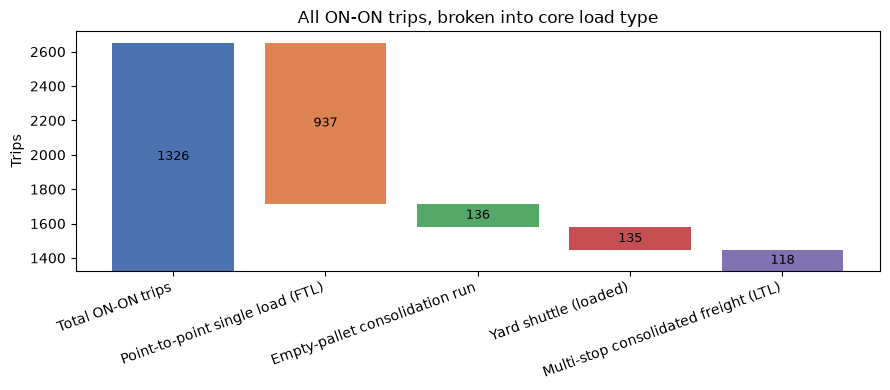

In [6]:
loaded_legs = dispatch[dispatch['LS_MT_LOADED'] == 'L']
pickup_legs = loaded_legs.loc[loaded_legs.groupby('TRIP_NUMBER')['LS_LEG_SEQ'].idxmin()]
core_type_counts = pickup_legs['run_type'].value_counts()
total_trips = dispatch['TRIP_NUMBER'].nunique()
assert core_type_counts.sum() == total_trips  # every trip has exactly one loaded leg to anchor on

steps = ['Total ON-ON trips'] + core_type_counts.index.tolist()
values = [total_trips] + (-core_type_counts).tolist()  # subtract each slice off the running total
bottoms, running = [], total_trips
for v in values:
    bottoms.append(running + min(v, 0))
    running += v

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4C72B0'] + ['#DD8452', '#55A868', '#C44E52', '#8172B2'][:len(core_type_counts)]
ax.bar(steps, [abs(v) for v in values], bottom=bottoms, color=colors)
for i, v in enumerate(values):
    ax.text(i, bottoms[i] + abs(v) / 2, str(abs(v)), ha='center', va='center', fontsize=9)
ax.set_ylabel('Trips')
ax.set_title('All ON-ON trips, broken into core load type')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

## 1b. Trip-level pattern: does each trip end in a deadhead or a loaded return? (zero-sum)

`run_type` is per-leg, so a trip touches more than one bucket. Rolling it up to one label per trip fixes that: take the trip's core load type (from its first loaded leg) and cross it with whether the *whole trip* also contains a real deadhead leg, more than one loaded leg with no deadhead (a round trip with a loaded return), or neither (a single-leg trip with nothing to compare). This sums to exactly the 1,326 distinct ON-ON trips — every trip counted once.

In [7]:
def classify_trip_pattern(legs):
    loaded_legs = legs[legs['LS_MT_LOADED'] == 'L']
    pickup_legs = loaded_legs.loc[loaded_legs.groupby('TRIP_NUMBER')['LS_LEG_SEQ'].idxmin()]
    core_type = pickup_legs.set_index('TRIP_NUMBER')['run_type']

    same_facility = legs['LS_FROM_ZONE'].astype(str) == legs['LS_TO_ZONE'].astype(str)
    real_deadhead = (legs['LS_MT_LOADED'] == 'E') & ~(same_facility & (legs['LS_LEG_DIST'] == 0))

    stats = pd.DataFrame({'TRIP_NUMBER': legs['TRIP_NUMBER'], '_deadhead': real_deadhead, '_loaded': legs['LS_MT_LOADED'] == 'L'}) \
        .groupby('TRIP_NUMBER').agg(num_loaded=('_loaded', 'sum'), has_deadhead=('_deadhead', 'any'))
    stats['core_type'] = core_type.reindex(stats.index)

    has_core = stats['core_type'].notna()
    round_trip = has_core & ~stats['has_deadhead'] & (stats['num_loaded'] > 1)
    single_leg = has_core & ~stats['has_deadhead'] & (stats['num_loaded'] == 1)
    with_deadhead = has_core & stats['has_deadhead']

    pattern = pd.Series('No load (pure repositioning trip)', index=stats.index)
    pattern[with_deadhead] = stats.loc[with_deadhead, 'core_type'] + ' + deadhead leg'
    pattern[round_trip] = stats.loc[round_trip, 'core_type'] + ' + loaded return (round trip)'
    pattern[single_leg] = stats.loc[single_leg, 'core_type'] + ' only (single load, no return)'
    return pattern


trip_pattern = classify_trip_pattern(dispatch)
assert trip_pattern.index.nunique() == dispatch['TRIP_NUMBER'].nunique()
trip_pattern.value_counts()

Point-to-point single load (FTL) + deadhead leg                        823
Yard shuttle (loaded) only (single load, no return)                    120
Empty-pallet consolidation run + deadhead leg                          120
Multi-stop consolidated freight (LTL) + deadhead leg                   112
Point-to-point single load (FTL) + loaded return (round trip)           93
Point-to-point single load (FTL) only (single load, no return)          21
Yard shuttle (loaded) + deadhead leg                                    13
Empty-pallet consolidation run only (single load, no return)            12
Multi-stop consolidated freight (LTL) + loaded return (round trip)       5
Empty-pallet consolidation run + loaded return (round trip)              4
Yard shuttle (loaded) + loaded return (round trip)                       2
Multi-stop consolidated freight (LTL) only (single load, no return)      1
Name: count, dtype: int64

In [8]:
pattern_split = trip_pattern.str.extract(r'^(.*?)( \+ deadhead leg| \+ loaded return \(round trip\)| only \(single load, no return\)|)$')
pattern_split.columns = ['core_type', 'return_pattern']
pattern_split['return_pattern'] = pattern_split['return_pattern'].replace({
    ' + deadhead leg': 'Had a deadhead leg', ' + loaded return (round trip)': 'Had a loaded return (round trip)',
    ' only (single load, no return)': 'Single leg, no return', '': 'No load in this trip'})

pivot = pd.crosstab(pattern_split['core_type'], pattern_split['return_pattern'])
pivot['TOTAL'] = pivot.sum(axis=1)
pivot

return_pattern,Had a deadhead leg,Had a loaded return (round trip),"Single leg, no return",TOTAL
core_type,,,,
Empty-pallet consolidation run,120,4,12,136
Multi-stop consolidated freight (LTL),112,5,1,118
Point-to-point single load (FTL),823,93,21,937
Yard shuttle (loaded),13,2,120,135


The pivot above lumps "empty pickup" and "empty post-delivery" into one "had a deadhead leg" column. Splitting that in two (a trip can have both, so these don't need to add to the deadhead total above):

In [9]:
has_pickup_empty = dispatch.groupby('TRIP_NUMBER')['run_type'].apply(lambda s: (s == 'Empty run to pickup (deadhead approach)').any())
has_postdel_empty = dispatch.groupby('TRIP_NUMBER')['run_type'].apply(lambda s: (s == 'Empty run after delivery (deadhead departure)').any())

empty_split = pattern_split.assign(has_pickup_empty=has_pickup_empty, has_postdel_empty=has_postdel_empty)

empty_split.groupby('core_type').agg(
    trips=('core_type', 'size'),
    pct_empty_pickup=('has_pickup_empty', lambda s: (s.mean() * 100).round(1)),
    pct_empty_postdelivery=('has_postdel_empty', lambda s: (s.mean() * 100).round(1)),
)

,trips,pct_empty_pickup,pct_empty_postdelivery
core_type,,,
Empty-pallet consolidation run,136,86.8,23.5
Multi-stop consolidated freight (LTL),118,81.4,30.5
Point-to-point single load (FTL),937,83.1,25.4
Yard shuttle (loaded),135,9.6,0.7


Those two percentages overlap (a trip can have both). The zero-sum version — every loaded trip lands in exactly one of four buckets:

In [10]:
EMPTY_PATTERNS = ['Neither', 'Empty pickup only', 'Empty post-delivery only', 'Both']
empty_pattern = pd.Series('Neither', index=has_pickup_empty.index)
empty_pattern[has_pickup_empty & ~has_postdel_empty] = 'Empty pickup only'
empty_pattern[~has_pickup_empty & has_postdel_empty] = 'Empty post-delivery only'
empty_pattern[has_pickup_empty & has_postdel_empty] = 'Both'
empty_split['empty_pattern'] = empty_pattern

assert empty_split['empty_pattern'].notna().sum() == len(empty_split)
pd.crosstab(empty_split['core_type'], empty_split['empty_pattern'])

empty_pattern,Both,Empty pickup only,Empty post-delivery only,Neither
core_type,,,,
Empty-pallet consolidation run,31,87,1,17
Multi-stop consolidated freight (LTL),31,65,5,17
Point-to-point single load (FTL),208,571,30,128
Yard shuttle (loaded),1,12,0,122


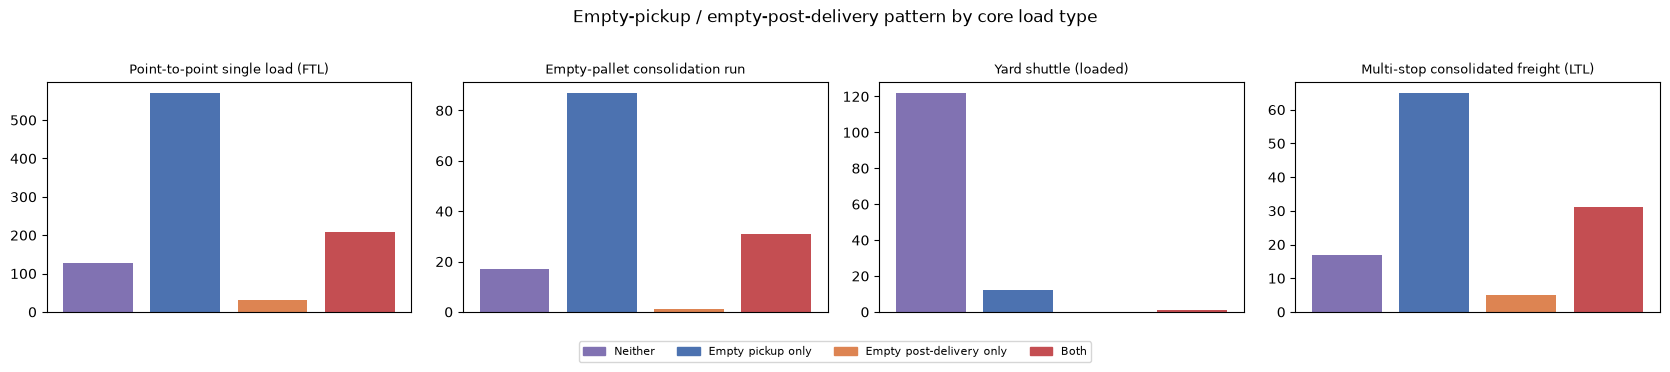

In [11]:
CORE_TYPES = pickup_legs['run_type'].value_counts().index.tolist()
EMPTY_PATTERN_COLORS = ['#8172B2', '#4C72B0', '#DD8452', '#C44E52']

def plot_empty_pattern(ax, core):
    counts = empty_split.loc[empty_split['core_type'] == core, 'empty_pattern'].value_counts().reindex(EMPTY_PATTERNS, fill_value=0)
    ax.bar(range(4), counts.values, color=EMPTY_PATTERN_COLORS)
    ax.set_xticks([])

fig, axes = facet_wrap(CORE_TYPES, plot_empty_pattern, ncols=4, title='Empty-pickup / empty-post-delivery pattern by core load type')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in EMPTY_PATTERN_COLORS]
fig.legend(handles, EMPTY_PATTERNS, loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=4, fontsize=8)
plt.show()

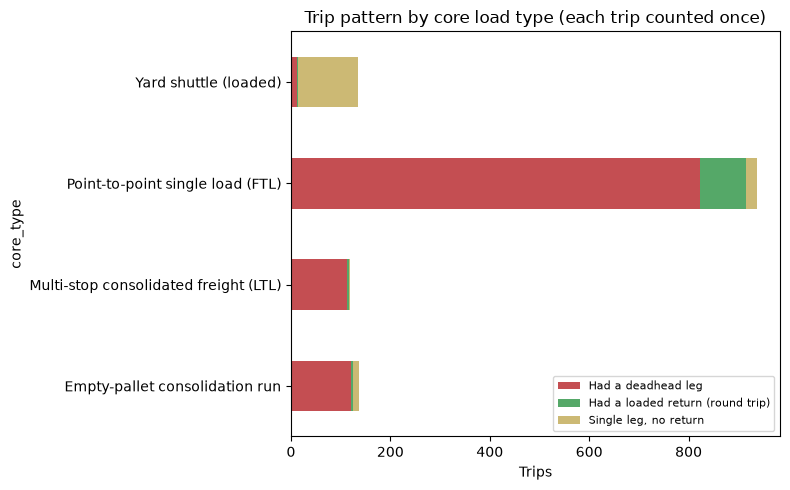

In [12]:
plot_cols = [c for c in ['Had a deadhead leg', 'Had a loaded return (round trip)', 'Single leg, no return', 'No load in this trip'] if c in pivot.columns]
fig, ax = plt.subplots(figsize=(8, 5))
pivot[plot_cols].plot(kind='barh', stacked=True, ax=ax, color=['#C44E52', '#55A868', '#CCB974', '#8172B2'])
ax.set_xlabel('Trips')
ax.set_title('Trip pattern by core load type (each trip counted once)')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

## 1c. Load weight and pallet count, by run type

Per the data dictionary, `WEIGHT_LBS`/`PALLETS` are joined down from the order onto every leg of it — including empty legs, which is why an "empty run" facet below still shows non-zero values: that's the weight of the load riding on an *adjacent* leg of the same order, carried onto a leg where nothing is actually being hauled, not real cargo on that empty leg. Read the four loaded facets (FTL, LTL, pallet-run, yard shuttle) as real; read the four empty-leg facets as an artifact of the join, not a road weight.

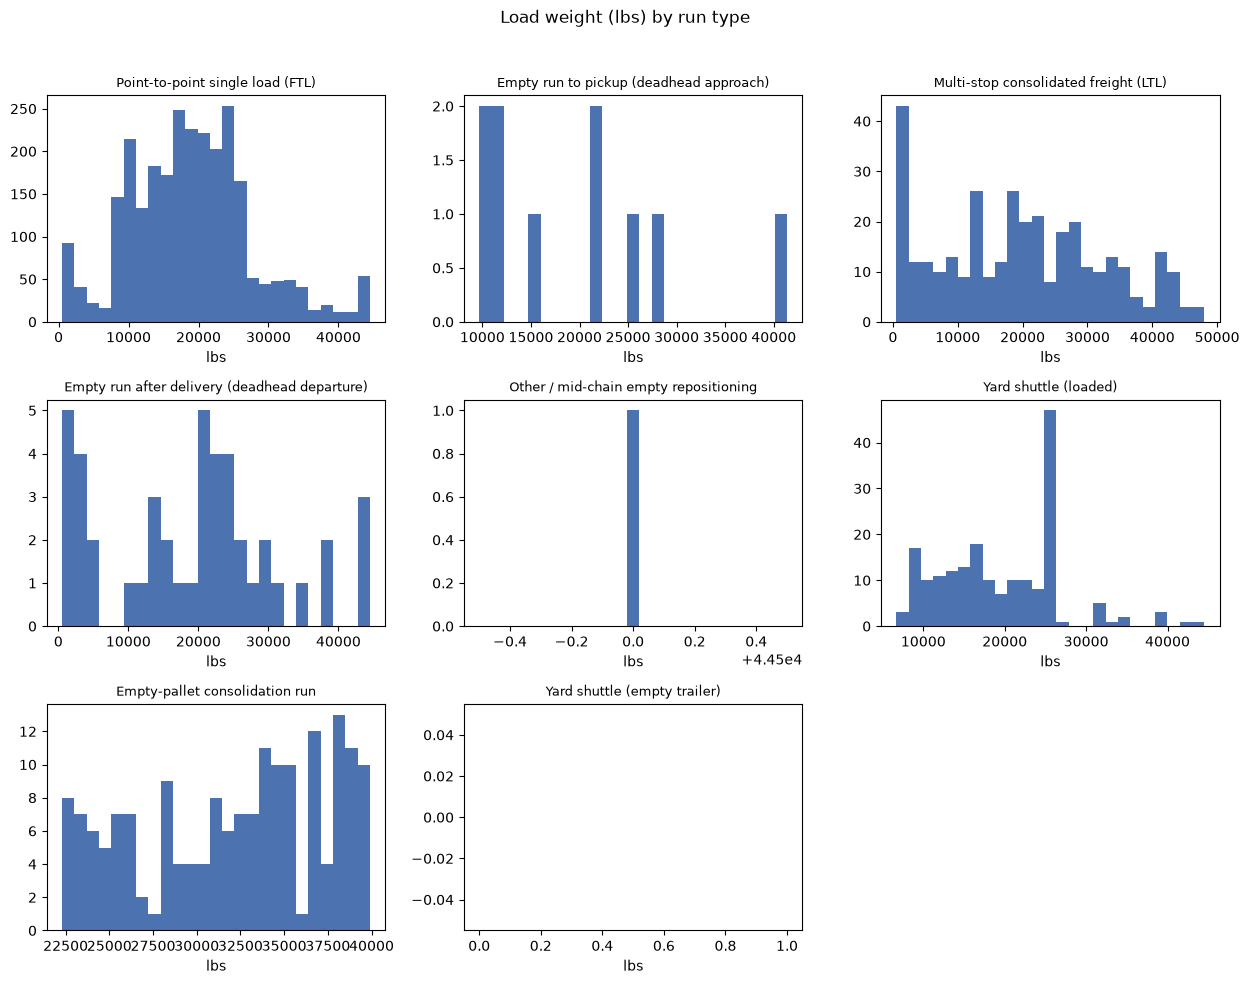

In [13]:
def plot_weight_hist(ax, run_type):
    vals = dispatch.loc[dispatch['run_type'] == run_type, 'WEIGHT_LBS'].dropna()
    ax.hist(vals, bins=25, color='#4C72B0')
    ax.set_xlabel('lbs')

facet_wrap(RUN_TYPES, plot_weight_hist, title='Load weight (lbs) by run type')
plt.show()

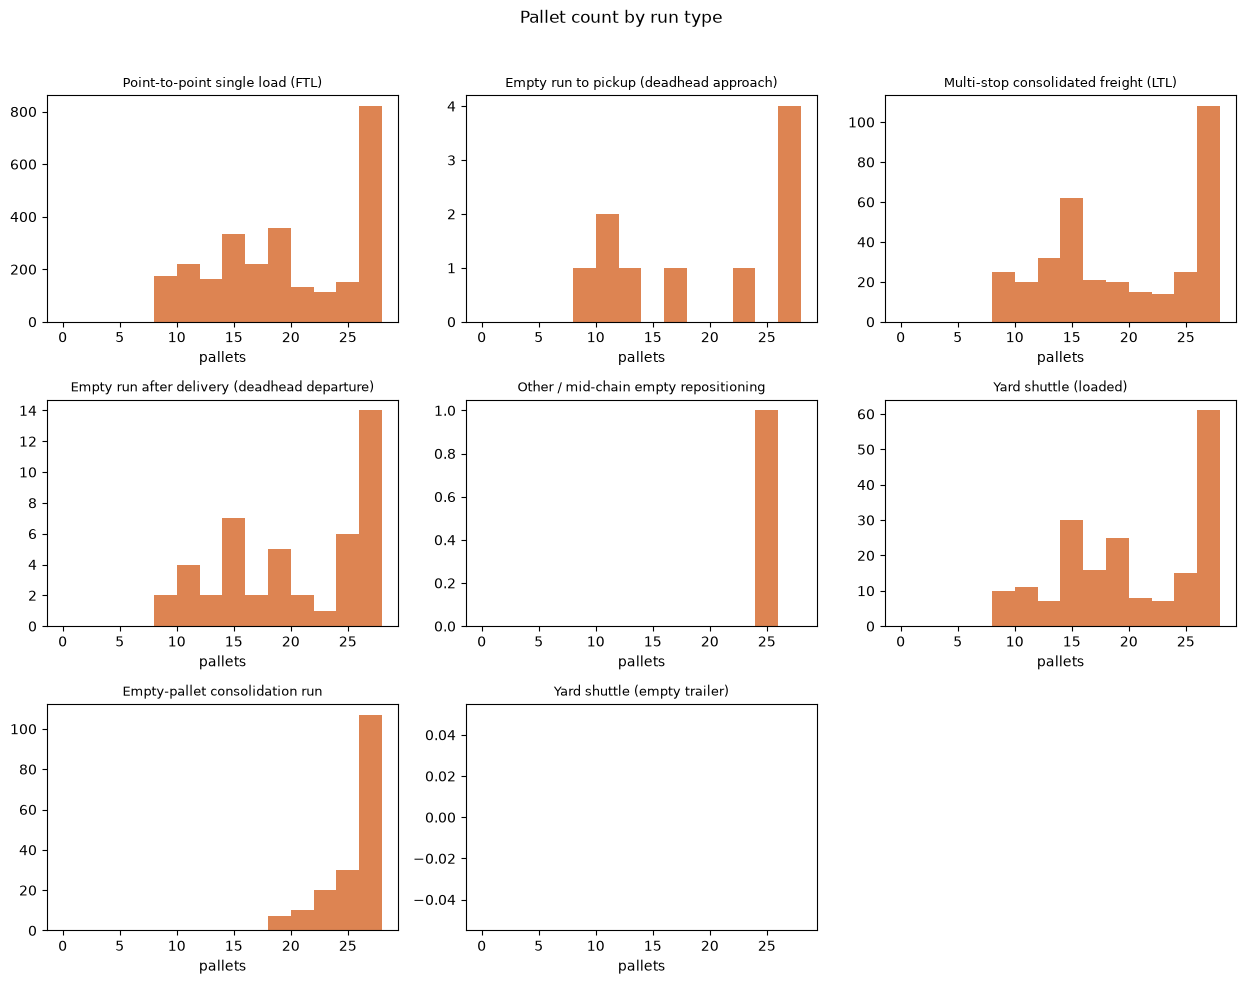

In [14]:
def plot_pallet_hist(ax, run_type):
    vals = dispatch.loc[dispatch['run_type'] == run_type, 'PALLETS'].dropna()
    ax.hist(vals, bins=range(0, 30, 2), color='#DD8452')
    ax.set_xlabel('pallets')

facet_wrap(RUN_TYPES, plot_pallet_hist, title='Pallet count by run type')
plt.show()

In [15]:
print('PLAN_DEPART range:', dispatch['PLAN_DEPART'].min(), 'to', dispatch['PLAN_DEPART'].max())

PLAN_DEPART range: 2026-06-22 06:00:00 to 2026-08-28 12:00:00


The ON-ON dispatch data already only spans about two months (late June to late August 2026) — every count above already is "the last 2 months," no extra date filter needed.

## 2. Distribution, average time, and leg-distance profile by run type

"Time taken" is leg-level dwell: arrival at the leg's pickup dock to arrival at its delivery dock (`LS_DET_PICK_ARRIVE` → `LS_DET_DELV_ARRIVE`). Pure empty legs rarely carry both timestamps, so their average is based on far fewer legs than their count suggests.

In [16]:
dispatch['arrive'] = pd.to_datetime(dispatch['LS_DET_PICK_ARRIVE'], errors='coerce')
dispatch['depart'] = pd.to_datetime(dispatch['LS_DET_DELV_ARRIVE'], errors='coerce')
dispatch['leg_duration_h'] = (dispatch['depart'] - dispatch['arrive']).dt.total_seconds() / 3600

summary = dispatch.groupby('run_type').agg(
    legs=('run_type', 'size'),
    avg_leg_dist_mi=('LS_LEG_DIST', 'mean'),
    avg_duration_h=('leg_duration_h', lambda s: s[s >= 0].mean()),
    legs_with_duration=('leg_duration_h', lambda s: (s >= 0).sum()),
).round(1).sort_values('legs', ascending=False)
summary

,legs,avg_leg_dist_mi,avg_duration_h,legs_with_duration
run_type,,,,
Point-to-point single load (FTL),2683,19.7,9.2,2656
Empty run to pickup (deadhead approach),1089,24.0,1.6,10
Multi-stop consolidated freight (LTL),342,50.0,4.1,340
Empty run after delivery (deadhead departure),327,19.1,1.8,44
Other / mid-chain empty repositioning,324,9.8,2.0,1
Yard shuttle (loaded),190,0.0,12.5,147
Empty-pallet consolidation run,174,81.3,46.9,170
Yard shuttle (empty trailer),63,0.0,NaN,0


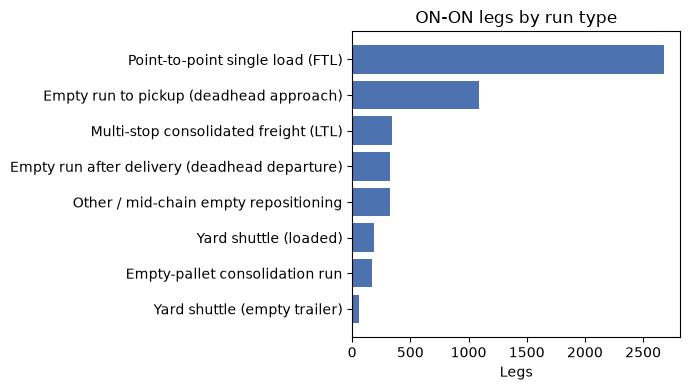

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(summary.index[::-1], summary['legs'][::-1], color='#4C72B0')
ax.set_xlabel('Legs')
ax.set_title('ON-ON legs by run type')
plt.tight_layout()
plt.show()

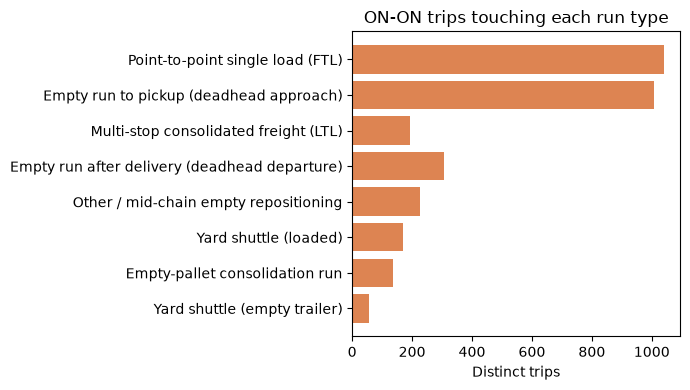

In [18]:
# run_type is per-leg, so one trip (e.g. an empty approach + its loaded haul) can contribute
# to more than one bar here -- these counts don't sum to the 1,326 distinct ON-ON trips.
trip_counts = dispatch.groupby('run_type')['TRIP_NUMBER'].nunique().reindex(summary.index)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(trip_counts.index[::-1], trip_counts.values[::-1], color='#DD8452')
ax.set_xlabel('Distinct trips')
ax.set_title('ON-ON trips touching each run type')
plt.tight_layout()
plt.show()

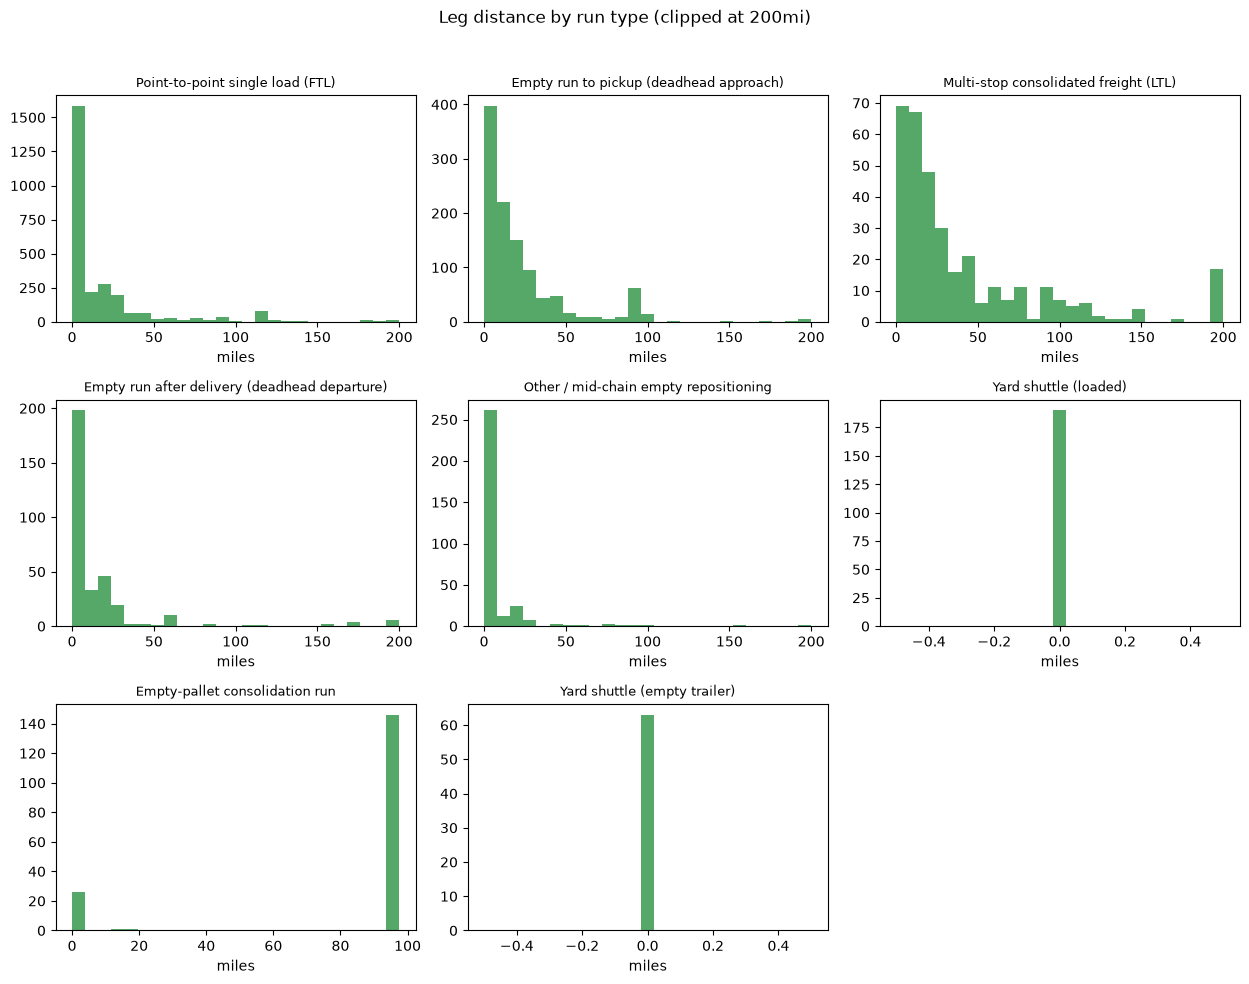

In [19]:
def plot_dist_hist(ax, run_type):
    vals = dispatch.loc[dispatch['run_type'] == run_type, 'LS_LEG_DIST']
    ax.hist(vals.clip(upper=200), bins=25, color='#55A868')
    ax.set_xlabel('miles')

facet_wrap(RUN_TYPES, plot_dist_hist, title='Leg distance by run type (clipped at 200mi)')
plt.show()

## 3. Last known freight-bill status, by run type

`LAST_FB_STATUS` is each leg's single most-recent status, not a full event history. Even so, the mix per run type is a sanity check: yard shuttles should land on end-states, not mid-process ones.

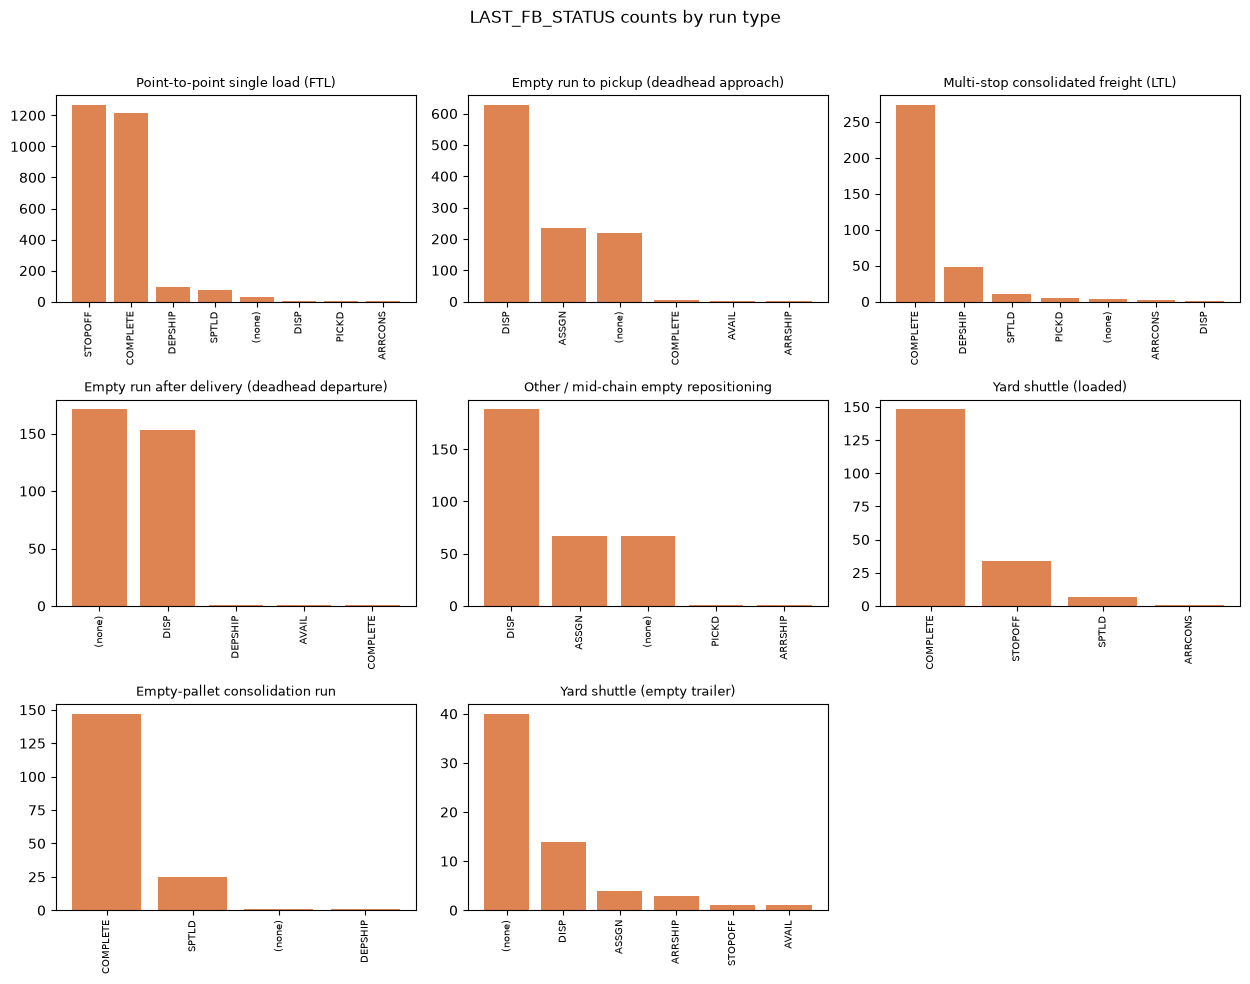

In [20]:
def plot_status_bar(ax, run_type):
    counts = dispatch.loc[dispatch['run_type'] == run_type, 'LAST_FB_STATUS'].fillna('(none)').value_counts()
    ax.bar(counts.index, counts.values, color='#DD8452')
    ax.tick_params(axis='x', rotation=90, labelsize=7)

facet_wrap(RUN_TYPES, plot_status_bar, title='LAST_FB_STATUS counts by run type')
plt.show()

### Transition matrix: what run type follows what

Each driver's own chronological leg sequence, one step at a time (there's no truck ID to follow instead — see section 9's note on that). Rows are the current leg's run type, columns are the very next leg this driver runs; counts and row-percentages (each row sums to 100%).

In [21]:
d_seq = dispatch.sort_values(['NAME', 'PLAN_DEPART', 'TRIP_NUMBER', 'LS_LEG_SEQ']).copy()
d_seq['next_run_type'] = d_seq.groupby('NAME')['run_type'].shift(-1)
transitions = d_seq.dropna(subset=['next_run_type'])
print(f'Legs with a next leg for the same driver: {len(transitions)} of {len(d_seq)}')

run_type_matrix = pd.crosstab(transitions['run_type'], transitions['next_run_type'])
run_type_matrix

Legs with a next leg for the same driver: 4887 of 5192


next_run_type,Empty run after delivery (deadhead departure),Empty run to pickup (deadhead approach),Empty-pallet consolidation run,Multi-stop consolidated freight (LTL),Other / mid-chain empty repositioning,Point-to-point single load (FTL),Yard shuttle (empty trailer),Yard shuttle (loaded)
run_type,,,,,,,,
Empty run after delivery (deadhead departure),0,245,0,0,70,0,2,0
Empty run to pickup (deadhead approach),0,0,127,83,0,865,0,14
Empty-pallet consolidation run,47,82,19,0,0,12,6,1
Multi-stop consolidated freight (LTL),15,37,0,130,0,149,2,8
Other / mid-chain empty repositioning,0,81,0,0,23,0,1,0
Point-to-point single load (FTL),264,599,16,123,0,1564,34,42
Yard shuttle (empty trailer),0,6,4,0,1,33,3,0
Yard shuttle (loaded),1,11,1,5,0,46,0,115


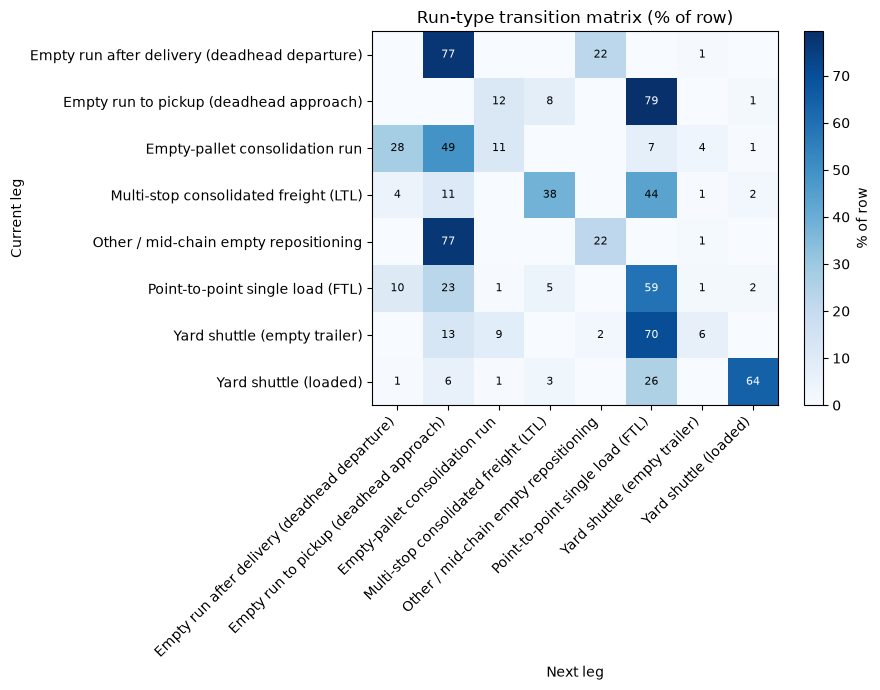

In [22]:
run_type_pct = run_type_matrix.div(run_type_matrix.sum(axis=1), axis=0) * 100
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(run_type_pct.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(run_type_pct.columns)))
ax.set_xticklabels(run_type_pct.columns, rotation=45, ha='right')
ax.set_yticks(range(len(run_type_pct.index)))
ax.set_yticklabels(run_type_pct.index)
for i in range(run_type_pct.shape[0]):
    for j in range(run_type_pct.shape[1]):
        val = run_type_pct.values[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=8,
                    color='white' if val > 50 else 'black')
ax.set_xlabel('Next leg')
ax.set_ylabel('Current leg')
ax.set_title('Run-type transition matrix (% of row)')
fig.colorbar(im, ax=ax, label='% of row')
plt.tight_layout()
plt.show()

### Transition matrix: run type vs. last known freight-bill status

The full cross-tab behind the facet chart above, as counts and as row-percentages (each run type's own status mix sums to 100%). Read it as a sanity check, not a state-transition model — `LAST_FB_STATUS` is one snapshot per leg, not a logged sequence of transitions.

In [23]:
status_counts = pd.crosstab(dispatch['run_type'], dispatch['LAST_FB_STATUS'].fillna('(none)'))
status_pct = status_counts.div(status_counts.sum(axis=1), axis=0) * 100
status_counts

LAST_FB_STATUS,(none),ARRCONS,ARRSHIP,ASSGN,AVAIL,COMPLETE,DEPSHIP,DISP,PICKD,SPTLD,STOPOFF
run_type,,,,,,,,,,,
Empty run after delivery (deadhead departure),171,0,0,0,1,1,1,153,0,0,0
Empty run to pickup (deadhead approach),219,0,1,235,1,6,0,627,0,0,0
Empty-pallet consolidation run,1,0,0,0,0,147,1,0,0,25,0
Multi-stop consolidated freight (LTL),3,2,0,0,0,273,48,1,5,10,0
Other / mid-chain empty repositioning,67,0,1,67,0,0,0,188,1,0,0
Point-to-point single load (FTL),28,3,0,0,0,1213,93,5,3,72,1266
Yard shuttle (empty trailer),40,0,3,4,1,0,0,14,0,0,1
Yard shuttle (loaded),0,1,0,0,0,148,0,0,0,7,34


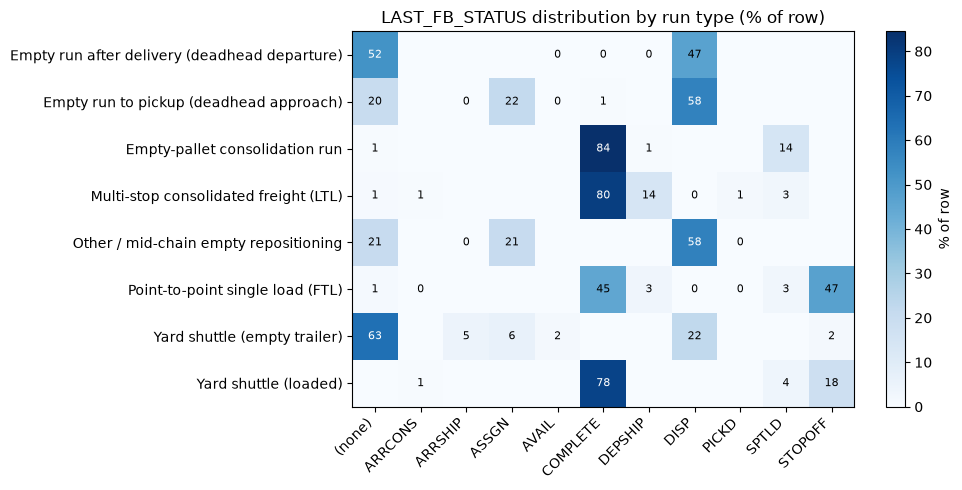

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(status_pct.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(status_pct.columns)))
ax.set_xticklabels(status_pct.columns, rotation=45, ha='right')
ax.set_yticks(range(len(status_pct.index)))
ax.set_yticklabels(status_pct.index)
for i in range(status_pct.shape[0]):
    for j in range(status_pct.shape[1]):
        val = status_pct.values[i, j]
        if val > 0:
            ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=8,
                    color='white' if val > 50 else 'black')
ax.set_title('LAST_FB_STATUS distribution by run type (% of row)')
fig.colorbar(im, ax=ax, label='% of row')
plt.tight_layout()
plt.show()

## 4. HOS exhaustion by run type: pickup wait, on route, or delivery wait?

Only the four *loaded* run types have a pickup→drive→delivery structure to chain (pure empty legs don't wait on freight). `REMAINING_HOURS` is a live snapshot, not a historical value for the trip being checked — comparing it to a decades-old wait is not reliable (see the caveats worked out earlier this session). What **is** reliable: whether the elapsed pickup-wait + drive + delivery-wait alone exceeds 70h, the maximum possible balance under *any* HOS cycle — that holds regardless of the driver's actual clock position. Trips with an implausible multi-day `drive_h` (a multi-stop join mismatch or, for pallet runs, a genuine multi-day consolidation wait) or missing timestamps are marked **Unknown** rather than silently dropped.

In [25]:
loaded_legs = dispatch[dispatch['LS_MT_LOADED'] == 'L'].copy()
pickup_legs = loaded_legs.loc[loaded_legs.groupby('TRIP_NUMBER')['LS_LEG_SEQ'].idxmin()]
delivery_legs = dispatch.loc[dispatch.groupby('TRIP_NUMBER')['LS_LEG_SEQ'].idxmax()]

timeline = pickup_legs[['TRIP_NUMBER', 'NAME', 'run_type', 'LS_DET_PICK_ARRIVE']].rename(columns={'LS_DET_PICK_ARRIVE': 'pu_arrive'})
timeline = timeline.merge(delivery_legs[['TRIP_NUMBER', 'LS_DET_DELV_ARRIVE']].rename(columns={'LS_DET_DELV_ARRIVE': 'dv_arrive'}), on='TRIP_NUMBER')
timeline = timeline.merge(tlorder[['TRIP_NUMBER', 'ACTUAL_PICKUP', 'ACTUAL_DELIVERY']], on='TRIP_NUMBER')
for c in ['pu_arrive', 'dv_arrive', 'ACTUAL_PICKUP', 'ACTUAL_DELIVERY']:
    timeline[c] = pd.to_datetime(timeline[c], errors='coerce')

LOADED_TYPES = pickup_legs['run_type'].value_counts().index.tolist()
totals_by_type = pickup_legs['run_type'].value_counts()

timeline = timeline.dropna(subset=['pu_arrive', 'ACTUAL_PICKUP', 'dv_arrive', 'ACTUAL_DELIVERY'])
timeline['pickup_wait_h'] = (timeline['ACTUAL_PICKUP'] - timeline['pu_arrive']).dt.total_seconds() / 3600
timeline['drive_h'] = (timeline['dv_arrive'] - timeline['ACTUAL_PICKUP']).dt.total_seconds() / 3600
timeline['delivery_wait_h'] = (timeline['ACTUAL_DELIVERY'] - timeline['dv_arrive']).dt.total_seconds() / 3600
timeline = timeline[(timeline['pickup_wait_h'] >= 0) & (timeline['drive_h'] >= 0) & (timeline['delivery_wait_h'] >= 0)]
timeline['plausible'] = timeline['drive_h'] <= 24

timeline['cum_after_pickup'] = timeline['pickup_wait_h']
timeline['cum_after_drive'] = timeline['cum_after_pickup'] + timeline['drive_h']
timeline['cum_after_delivery'] = timeline['cum_after_drive'] + timeline['delivery_wait_h']
len(timeline)

1052

In [26]:
t = timeline[timeline['plausible']].copy()
t['hos_stage'] = 'None (completed within a full 70h cycle)'
t.loc[t['cum_after_delivery'] > 70, 'hos_stage'] = 'Ran out during delivery wait'
t.loc[t['cum_after_drive'] > 70, 'hos_stage'] = 'Ran out while driving (en route)'
t.loc[t['cum_after_pickup'] > 70, 'hos_stage'] = 'Ran out during pickup wait'

assessed_by_type = t.groupby('run_type').size()
hos_summary = pd.DataFrame({
    'total_trips': totals_by_type,
    'assessed': assessed_by_type.reindex(totals_by_type.index, fill_value=0),
})
hos_summary['unknown'] = hos_summary['total_trips'] - hos_summary['assessed']
hos_summary

,total_trips,assessed,unknown
run_type,,,
Point-to-point single load (FTL),937,730,207
Empty-pallet consolidation run,136,108,28
Yard shuttle (loaded),135,85,50
Multi-stop consolidated freight (LTL),118,92,26


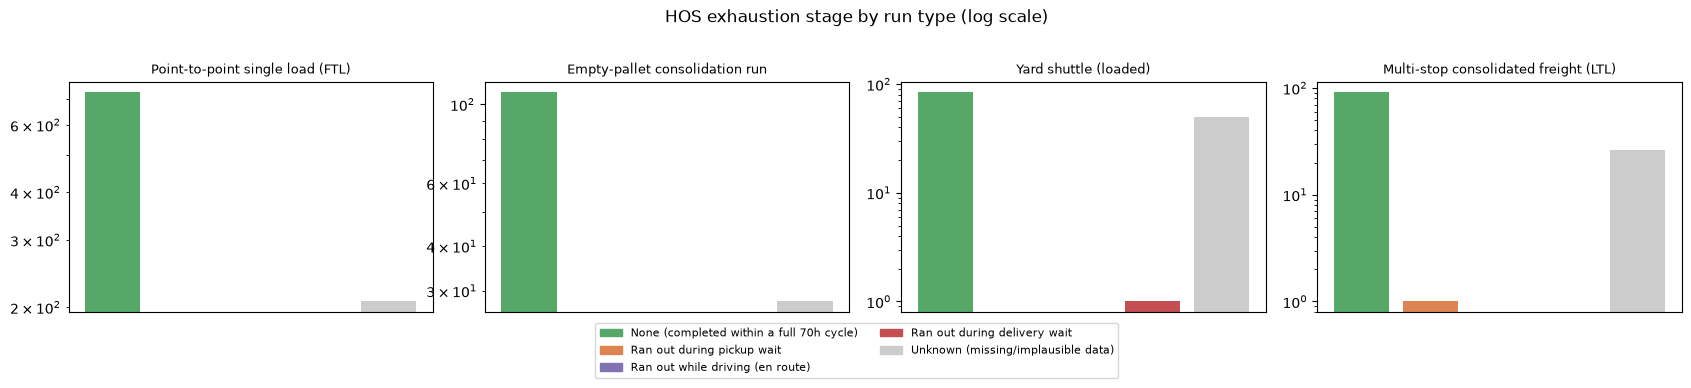

In [27]:
HOS_STAGES = ['None (completed within a full 70h cycle)', 'Ran out during pickup wait',
              'Ran out while driving (en route)', 'Ran out during delivery wait', 'Unknown (missing/implausible data)']
HOS_STAGE_COLORS = ['#55A868', '#DD8452', '#8172B2', '#C44E52', '#CCCCCC']

def plot_hos_bar(ax, run_type):
    sub = t.loc[t['run_type'] == run_type, 'hos_stage']
    unknown_n = hos_summary.loc[run_type, 'unknown']
    counts = sub.value_counts().reindex(HOS_STAGES[:-1], fill_value=0)
    counts['Unknown (missing/implausible data)'] = unknown_n
    ax.bar(range(len(counts)), counts.values, color=HOS_STAGE_COLORS)
    ax.set_xticks([])

fig, axes = facet_wrap(LOADED_TYPES, plot_hos_bar, ncols=4, title='HOS exhaustion stage by run type (log scale)')
for ax in axes[:len(LOADED_TYPES)]:
    ax.set_yscale('log')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in HOS_STAGE_COLORS]
fig.legend(handles, HOS_STAGES, loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=8)
plt.show()

## 5. What happens right after each run type finishes

Each `(driver, trip)` pair's last leg is where that run ends; the next leg for the same driver shows what happens next — reloaded immediately, an empty leg going nowhere (same city), or a genuine empty reposition to a new city.

In [28]:
seg_idx_last = dispatch.groupby(['NAME', 'TRIP_NUMBER'])['LS_LEG_SEQ'].idxmax()
seg_idx_first = dispatch.groupby(['NAME', 'TRIP_NUMBER'])['LS_LEG_SEQ'].idxmin()
last_leg = dispatch.loc[seg_idx_last]
first_leg = dispatch.loc[seg_idx_first]

seg = last_leg[['NAME', 'TRIP_NUMBER', 'run_type', 'DEST_ZONE_DESC', 'LS_DET_DELV_ARRIVE', 'DELIVER_BY', 'REMAINING_HOURS']].rename(
    columns={'DEST_ZONE_DESC': 'end_zone', 'run_type': 'completed_run_type'})
seg = seg.merge(
    first_leg[['NAME', 'TRIP_NUMBER', 'LS_MT_LOADED', 'ORIG_ZONE_DESC', 'PLAN_DEPART', 'LS_LEG_DIST']]
        .rename(columns={'LS_MT_LOADED': 'next_mt', 'ORIG_ZONE_DESC': 'next_orig', 'LS_LEG_DIST': 'next_dist'}),
    on=['NAME', 'TRIP_NUMBER'])

seg['end_time'] = pd.to_datetime(seg['LS_DET_DELV_ARRIVE'], errors='coerce').fillna(pd.to_datetime(seg['DELIVER_BY'], errors='coerce'))
seg['start_time'] = pd.to_datetime(seg['PLAN_DEPART'], errors='coerce')
seg = seg.dropna(subset=['end_time', 'start_time']).sort_values(['NAME', 'start_time'])

norm = lambda s: s.astype(str).str.upper().str.replace(' ', '', regex=False).str.strip()
seg['end_zone_n'] = norm(seg['end_zone'])
seg['next_orig_n'] = norm(seg['next_orig'])

seg[['next_mt', 'next_orig_n', 'next_dist', 'start_time']] = seg.groupby('NAME')[
    ['next_mt', 'next_orig_n', 'next_dist', 'start_time']].shift(-1)

trans = seg.dropna(subset=['next_mt']).copy()
trans['idle_gap_hours'] = (trans['start_time'] - trans['end_time']).dt.total_seconds() / 3600
trans = trans[trans['idle_gap_hours'] >= 0]

trans.loc[trans['next_mt'] == 'L', 'outcome'] = 'Reloaded immediately (no deadhead)'
trans.loc[(trans['next_mt'] == 'E') & (trans['end_zone_n'] == trans['next_orig_n']), 'outcome'] = 'Empty leg, same city (~0mi)'
trans['outcome'] = trans['outcome'].fillna('Repositioned empty to new city')

pd.crosstab(trans['completed_run_type'], trans['outcome'])

outcome,"Empty leg, same city (~0mi)",Reloaded immediately (no deadhead),Repositioned empty to new city
completed_run_type,,,
Empty run after delivery (deadhead departure),110,0,38
Empty run to pickup (deadhead approach),0,58,0
Empty-pallet consolidation run,46,7,15
Multi-stop consolidated freight (LTL),26,45,2
Other / mid-chain empty repositioning,7,0,3
Point-to-point single load (FTL),306,210,143
Yard shuttle (empty trailer),1,1,3
Yard shuttle (loaded),1,110,7


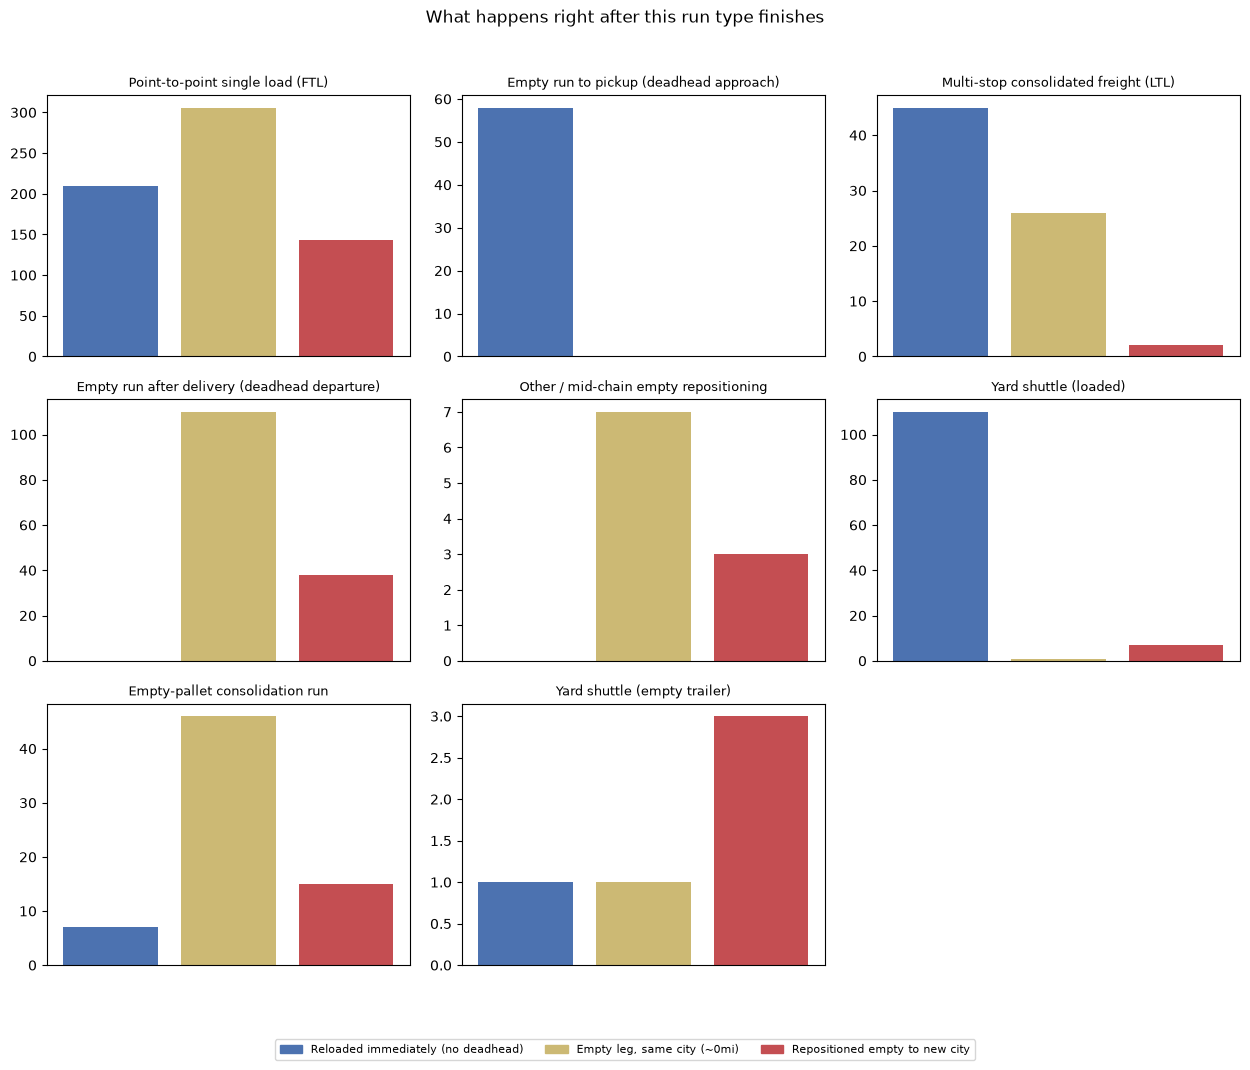

In [29]:
OUTCOMES = ['Reloaded immediately (no deadhead)', 'Empty leg, same city (~0mi)', 'Repositioned empty to new city']
OUTCOME_COLORS = ['#4C72B0', '#CCB974', '#C44E52']

def plot_outcome_bar(ax, run_type):
    counts = trans.loc[trans['completed_run_type'] == run_type, 'outcome'].value_counts().reindex(OUTCOMES, fill_value=0)
    ax.bar(range(3), counts.values, color=OUTCOME_COLORS)
    ax.set_xticks([])

fig, axes = facet_wrap(RUN_TYPES, plot_outcome_bar, title='What happens right after this run type finishes')
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in OUTCOME_COLORS]
fig.legend(handles, OUTCOMES, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=8)
plt.show()

## 6. The real cost: driving empty *after* a delivery, for no revenue

Empty-to-pickup isn't the concern — that's just how a truck gets to its next load, and the brief's own "Deadhead & Empty Mile Reduction" requirement (proximity-based load matching for a *return* shipment) only ever treats the post-delivery leg as the problem. Since `run_type` now resolves empty-leg adjacency across each driver's whole chronological history (not reset at every trip-number boundary — see the validation above), `Empty run after delivery (deadhead departure)` is already the single, correct measure of this: no separate cross-trip step needed, and no risk of counting the same gap twice.

Empty-after-delivery legs: 327, total no-revenue miles: 6,255


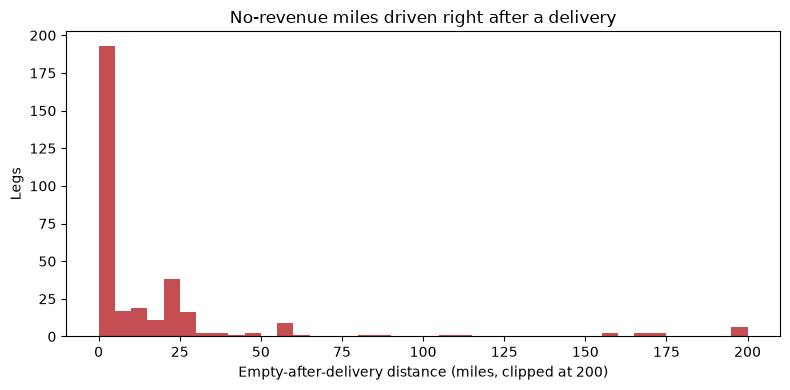

In [30]:
postdel = dispatch.loc[dispatch['run_type'] == 'Empty run after delivery (deadhead departure)', 'LS_LEG_DIST']
print(f'Empty-after-delivery legs: {len(postdel)}, total no-revenue miles: {postdel.sum():,.0f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(postdel.clip(upper=200), bins=40, color='#C44E52')
ax.set_xlabel('Empty-after-delivery distance (miles, clipped at 200)')
ax.set_ylabel('Legs')
ax.set_title('No-revenue miles driven right after a delivery')
plt.tight_layout()
plt.show()

In [31]:
postdel_legs = dispatch[dispatch['run_type'] == 'Empty run after delivery (deadhead departure)'].copy()
postdel_legs['preceding_load_type'] = postdel_legs['TRIP_NUMBER'].map(pattern_split['core_type'])

postdel_by_type = postdel_legs.groupby('preceding_load_type')['LS_LEG_DIST'].agg(legs='size', total_miles='sum', avg_miles='mean').round(1)
postdel_by_type

,legs,total_miles,avg_miles
preceding_load_type,,,
Empty-pallet consolidation run,34,349.3,10.3
Multi-stop consolidated freight (LTL),38,2109.6,55.5
Point-to-point single load (FTL),254,3775.9,14.9
Yard shuttle (loaded),1,20.2,20.2


**Corrected figure: 327 legs, 6,255 no-revenue miles** — down from an earlier (wrong) combined estimate of 10,679, because that number came from adding two boundary-blind, overlapping counts together rather than one properly-scoped one. FTL deliveries still generate the most cases (254 of 327), but LTL's are the longest when they happen (55.5 miles average vs FTL's 14.9) — a multi-stop delivery tends to end further from the next available load than a direct drop does.

## 7. Geofencing gaps and detention billing, by run type

One pickup event and one delivery event per trip: arrival (`LS_DET_PICK_ARRIVE`/`LS_DET_DELV_ARRIVE`) vs. completion (`Tlorder.ACTUAL_PICKUP`/`ACTUAL_DELIVERY`, aggregated to one value per trip so a multi-line order doesn't get fanned out into duplicate rows). A trip is missing geofence data if either timestamp is absent; that's the case for automatic detention billing to fail outright.

In [32]:
tl_agg = tlorder.groupby('TRIP_NUMBER').agg(
    ACTUAL_PICKUP=('ACTUAL_PICKUP', lambda s: pd.to_datetime(s, errors='coerce').min()),
    ACTUAL_DELIVERY=('ACTUAL_DELIVERY', lambda s: pd.to_datetime(s, errors='coerce').max()),
).reset_index()

pu = pickup_legs[['TRIP_NUMBER', 'NAME', 'run_type', 'LS_DET_PICK_ARRIVE']].merge(tl_agg[['TRIP_NUMBER', 'ACTUAL_PICKUP']], on='TRIP_NUMBER')
pu['arrive'], pu['done'], pu['event'] = pd.to_datetime(pu['LS_DET_PICK_ARRIVE'], errors='coerce'), pu['ACTUAL_PICKUP'], 'Pickup'

dv = delivery_legs[['TRIP_NUMBER', 'NAME', 'run_type', 'LS_DET_DELV_ARRIVE']].merge(tl_agg[['TRIP_NUMBER', 'ACTUAL_DELIVERY']], on='TRIP_NUMBER')
dv['arrive'], dv['done'], dv['event'] = pd.to_datetime(dv['LS_DET_DELV_ARRIVE'], errors='coerce'), dv['ACTUAL_DELIVERY'], 'Delivery'

cols = ['NAME', 'TRIP_NUMBER', 'run_type', 'event', 'arrive', 'done']
dock = pd.concat([pu[cols], dv[cols]], ignore_index=True)
dock['missing'] = dock['arrive'].isna() | dock['done'].isna()
len(dock)

2652

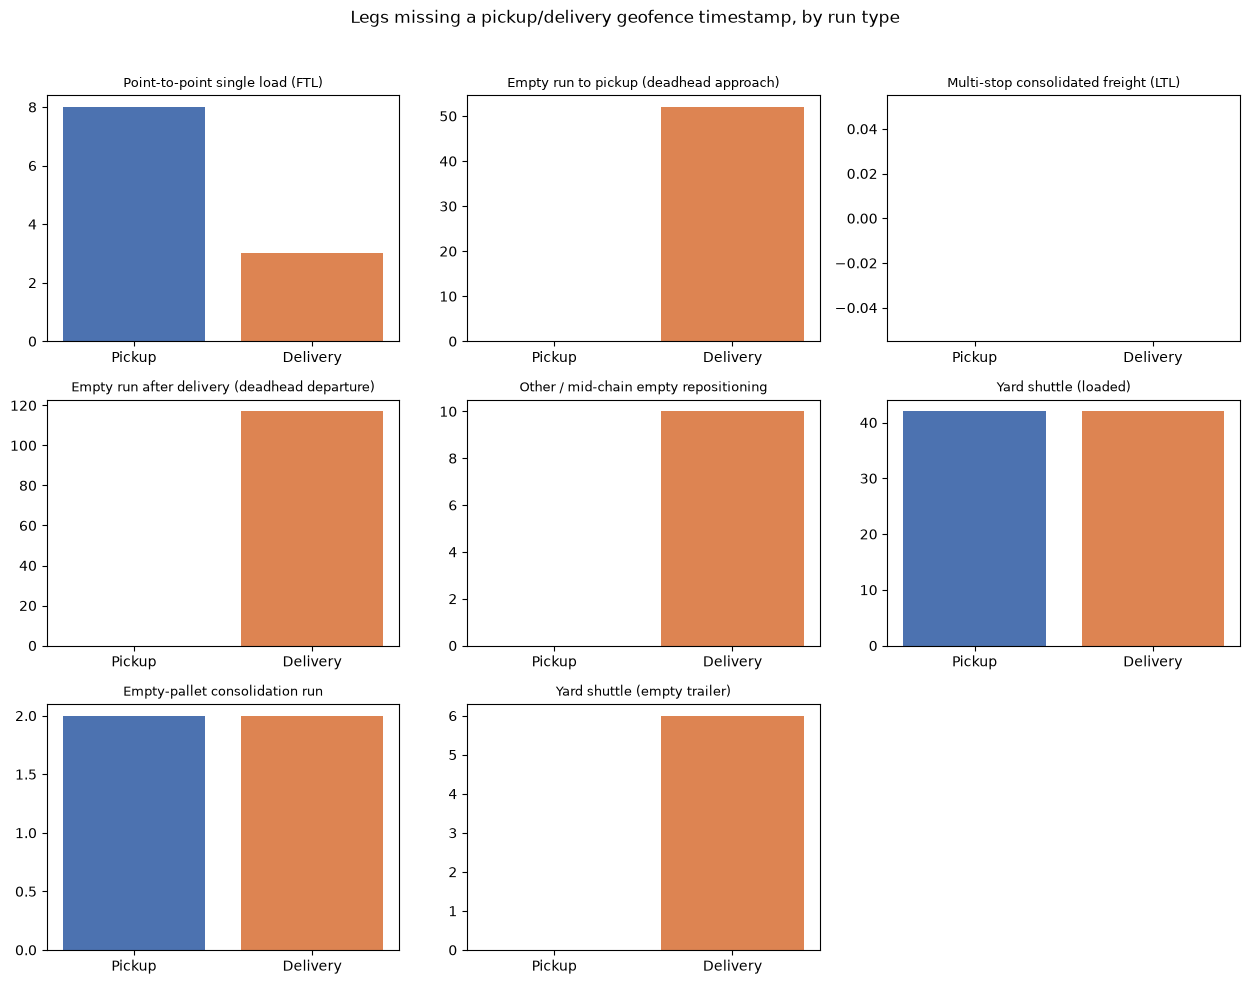

In [33]:
def plot_missing_bar(ax, run_type):
    counts = dock.loc[dock['run_type'] == run_type].groupby('event')['missing'].sum().reindex(['Pickup', 'Delivery'], fill_value=0)
    ax.bar(counts.index, counts.values, color=['#4C72B0', '#DD8452'])

facet_wrap(RUN_TYPES, plot_missing_bar, ncols=3, title='Legs missing a pickup/delivery geofence timestamp, by run type')
plt.show()

In [34]:
dock2 = dock[~dock['missing']].copy()
dock2['dwell_hours'] = (dock2['done'] - dock2['arrive']).dt.total_seconds() / 3600
dock2 = dock2[dock2['dwell_hours'] >= 0]  # negative = a data-quality mismatch, not real dwell
dock2['billable_hours'] = (dock2['dwell_hours'] - 2).clip(lower=0)

billing_summary = pd.DataFrame({
    'trip_events_checked': dock2.groupby('run_type').size(),
    'billable_over_2h': dock2[dock2['billable_hours'] > 0].groupby('run_type').size(),
    'total_billable_hours': dock2.groupby('run_type')['billable_hours'].sum().round(1),
}).fillna(0)
billing_summary.loc['ALL RUN TYPES'] = [len(dock2), (dock2['billable_hours'] > 0).sum(), dock2['billable_hours'].sum().round(1)]
billing_summary

,trip_events_checked,billable_over_2h,total_billable_hours
run_type,,,
Empty run after delivery (deadhead departure),39.0,1.0,1.8
Empty run to pickup (deadhead approach),5.0,0.0,0.0
Empty-pallet consolidation run,249.0,0.0,0.0
Multi-stop consolidated freight (LTL),153.0,3.0,2.8
Other / mid-chain empty repositioning,1.0,1.0,1.7
Point-to-point single load (FTL),1472.0,62.0,82.8
Yard shuttle (loaded),184.0,5.0,192.3
ALL RUN TYPES,2103.0,72.0,281.4


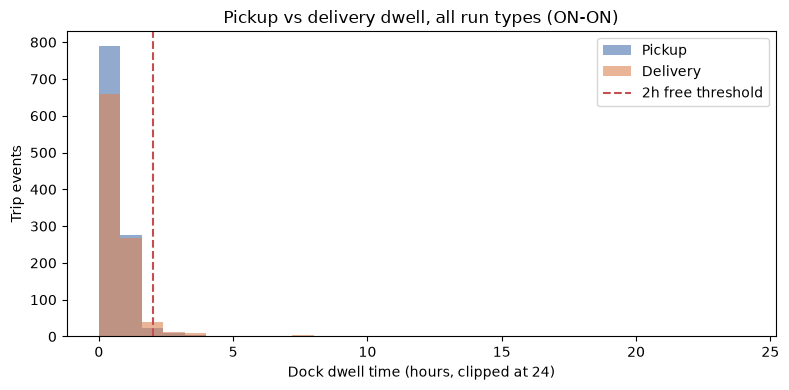

In [35]:
fig, ax = plt.subplots(figsize=(8, 4))
for event, color in [('Pickup', '#4C72B0'), ('Delivery', '#DD8452')]:
    ax.hist(dock2.loc[dock2['event'] == event, 'dwell_hours'].clip(upper=24), bins=30, alpha=0.6, label=event, color=color)
ax.axvline(2, color='#C44E52', linestyle='--', label='2h free threshold')
ax.set_xlabel('Dock dwell time (hours, clipped at 24)')
ax.set_ylabel('Trip events')
ax.set_title('Pickup vs delivery dwell, all run types (ON-ON)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Hours left on the driver's clock when the trip ends

`REMAINING_HOURS` here is each driver's live snapshot, not a value pinned to the moment this specific trip ended — so read this as "what a driver finishing this kind of run typically has on their clock," not a per-trip fact. It's still the right lens for a real operational question: is there normally enough legal drive time left to send the same driver straight into a deadhead or another load, versus needing a fresh driver?

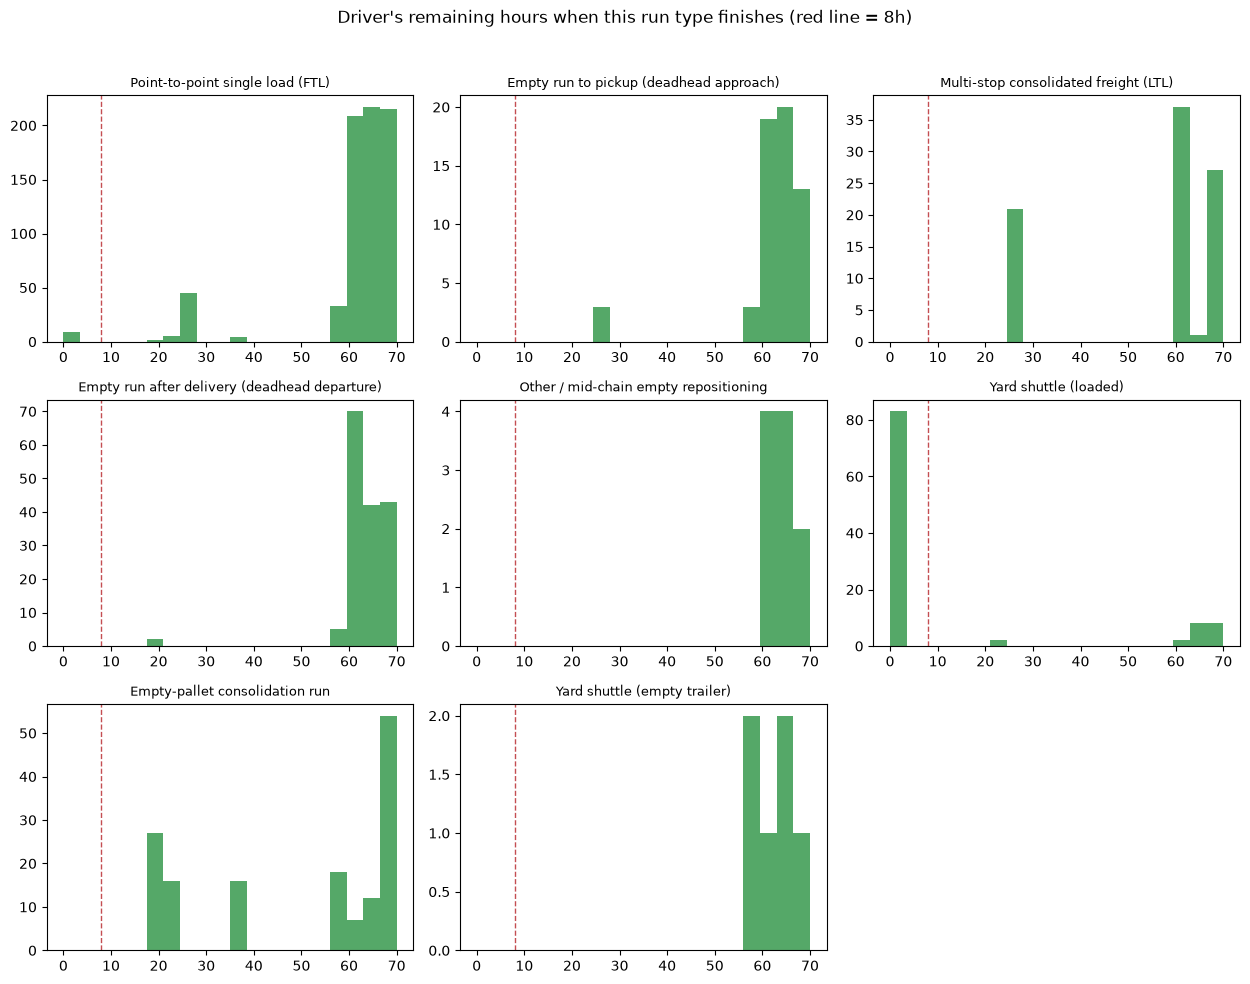

In [36]:
def plot_hours_left(ax, run_type):
    vals = seg.loc[seg['completed_run_type'] == run_type, 'REMAINING_HOURS'].dropna()
    ax.hist(vals, bins=20, range=(0, 70), color='#55A868')
    ax.axvline(8, color='#C44E52', linestyle='--', linewidth=1)

facet_wrap(RUN_TYPES, plot_hours_left, title="Driver's remaining hours when this run type finishes (red line = 8h)")
plt.show()

In [37]:
hours_left = seg.groupby('completed_run_type')['REMAINING_HOURS'].agg(
    trips='size', median_hours_left='median', pct_with_8h_plus=lambda s: (s >= 8).mean() * 100
).round(1)
hours_left

,trips,median_hours_left,pct_with_8h_plus
completed_run_type,,,
Empty run after delivery (deadhead departure),163,63.5,99.4
Empty run to pickup (deadhead approach),58,63.6,100.0
Empty-pallet consolidation run,150,57.8,100.0
Multi-stop consolidated freight (LTL),86,63.0,100.0
Other / mid-chain empty repositioning,10,63.7,100.0
Point-to-point single load (FTL),800,63.5,91.2
Yard shuttle (empty trailer),6,63.4,100.0
Yard shuttle (loaded),139,0.0,14.4


Most run types finish with a healthy median balance (50-65h) — plenty of legal time for the same driver to continue straight into the next dispatch. **Yard shuttle (loaded) is the clear outlier**, with a far lower median: the drivers who do this work are disproportionately the same few local/yard drivers whose live HOS snapshot already reads near zero (see the earlier sampling in this session) — a reminder that "how many hours are left" for this group needs its own tracking, not the OTR fleet's.

## 9. Time to the next pickup, FTL/LTL deliveries only

The ask was to flag whether the next pickup is the same driver or a different one. Checked whether that's answerable first: there's **no truck/power-unit ID anywhere in `Dispatch`**, `Driver.DEFAULT_PUNIT` is populated for only 18 of 131 active drivers, and the one place a genuine "different driver, same trip" handoff could be checked — 56 FTL/LTL trips where a second loaded leg is worked by a different driver — turned up **68 of 68 candidate pairs with a *negative* time gap** (the "next" driver's pickup timestamped *before* the previous driver's delivery, median -40.6h). That's not a real handoff; it's the same duplicate/candidate-driver record pattern already documented earlier in this session, not a sequential event. So a same-vs-different-driver split isn't something this data can honestly support — what follows is the one thing it can: each driver's own time to their next pickup.

In [38]:
FTL_LTL = ['Point-to-point single load (FTL)', 'Multi-stop consolidated freight (LTL)']

d = dispatch.sort_values(['NAME', 'PLAN_DEPART', 'TRIP_NUMBER', 'LS_LEG_SEQ']).copy()
d['arrive'] = pd.to_datetime(d['LS_DET_PICK_ARRIVE'], errors='coerce')
d['depart'] = pd.to_datetime(d['LS_DET_DELV_ARRIVE'], errors='coerce')

# next loaded leg's pickup-arrival time for this driver, walking forward past any empty legs
load_arrive = d['arrive'].where(d['LS_MT_LOADED'] == 'L')
d['next_load_arrive'] = load_arrive.groupby(d['NAME']).transform(lambda s: s.shift(-1).bfill())

deliveries = d[(d['LS_MT_LOADED'] == 'L') & (d['TRIP_NUMBER'].map(pattern_split['core_type']).isin(FTL_LTL))].copy()
deliveries = deliveries.dropna(subset=['depart', 'next_load_arrive'])
deliveries['time_to_next_pickup_h'] = (deliveries['next_load_arrive'] - deliveries['depart']).dt.total_seconds() / 3600
deliveries = deliveries[deliveries['time_to_next_pickup_h'] >= 0]

print(f'FTL/LTL deliveries with a valid time-to-next-pickup: {len(deliveries)}')
deliveries['time_to_next_pickup_h'].describe()

FTL/LTL deliveries with a valid time-to-next-pickup: 1226


count    1226.000000
mean       28.127278
std        47.023628
min         0.000000
25%         1.535139
50%        12.814306
75%        28.529792
max       624.768611
Name: time_to_next_pickup_h, dtype: float64

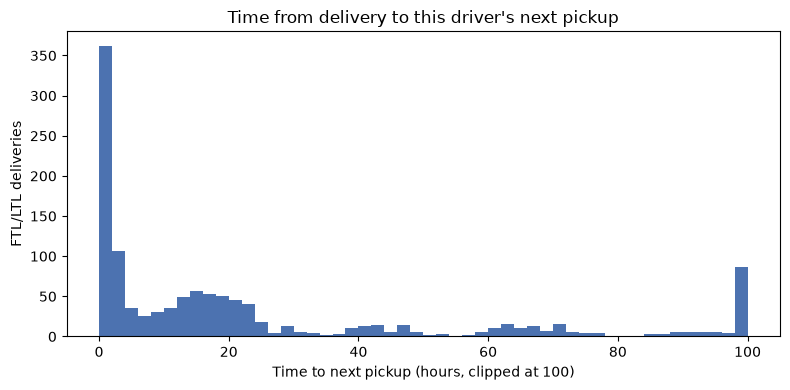

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(deliveries['time_to_next_pickup_h'].clip(upper=100), bins=50, color='#4C72B0')
ax.set_xlabel('Time to next pickup (hours, clipped at 100)')
ax.set_ylabel('FTL/LTL deliveries')
ax.set_title('Time from delivery to this driver\'s next pickup')
plt.tight_layout()
plt.show()

### The deadhead portion specifically: distance and duration

Distance (`LS_LEG_DIST`) is populated on every leg. Duration needs the empty leg's own dock arrival/departure timestamps, and those are largely absent for empty legs (they're a pickup/delivery-event field, not a mid-route one) — reported with that coverage caveat rather than papered over.

In [40]:
postdel = dispatch[dispatch['run_type'] == 'Empty run after delivery (deadhead departure)'].copy()
postdel['preceding_type'] = postdel['TRIP_NUMBER'].map(pattern_split['core_type'])
postdel_ftlltl = postdel[postdel['preceding_type'].isin(FTL_LTL)].copy()

postdel_ftlltl['arrive'] = pd.to_datetime(postdel_ftlltl['LS_DET_PICK_ARRIVE'], errors='coerce')
postdel_ftlltl['depart'] = pd.to_datetime(postdel_ftlltl['LS_DET_DELV_ARRIVE'], errors='coerce')
postdel_ftlltl['duration_h'] = (postdel_ftlltl['depart'] - postdel_ftlltl['arrive']).dt.total_seconds() / 3600

print(f'FTL/LTL empty-after-delivery legs: {len(postdel_ftlltl)}')
print(f'  distance available: {postdel_ftlltl["LS_LEG_DIST"].notna().sum()} legs')
print(f'  duration available: {(postdel_ftlltl["duration_h"] >= 0).sum()} legs ({(postdel_ftlltl["duration_h"] >= 0).mean()*100:.0f}%)')
print()
print('Distance (miles):')
print(postdel_ftlltl['LS_LEG_DIST'].describe())
print()
print('Duration (hours, where available):')
print(postdel_ftlltl.loc[postdel_ftlltl['duration_h'] >= 0, 'duration_h'].describe())

FTL/LTL empty-after-delivery legs: 292
  distance available: 292 legs
  duration available: 44 legs (15%)

Distance (miles):
count    292.000000
mean      20.155822
std       49.387858
min        0.000000
25%        2.400000
50%        2.800000
75%       21.100000
max      402.600000
Name: LS_LEG_DIST, dtype: float64

Duration (hours, where available):
count    44.000000
mean      1.776484
std       1.137684
min       0.000000
25%       1.018542
50%       1.939722
75%       2.160278
max       6.616667
Name: duration_h, dtype: float64


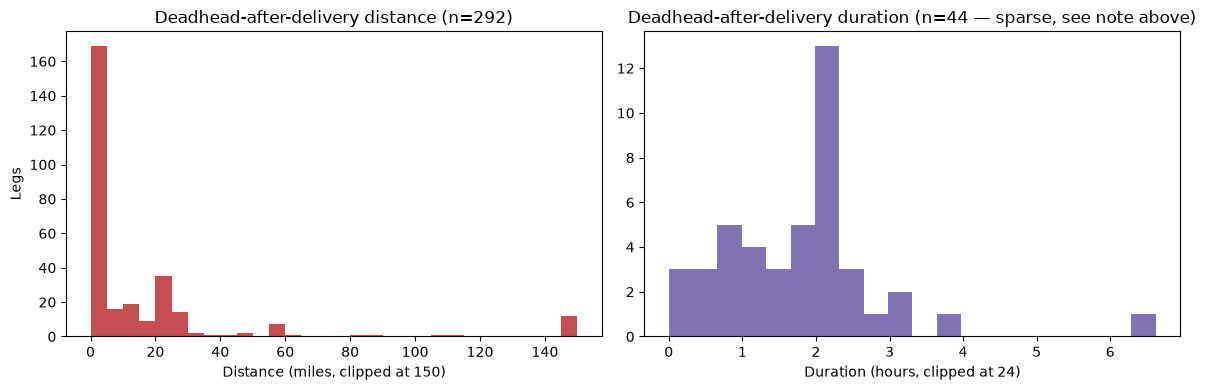

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(postdel_ftlltl['LS_LEG_DIST'].clip(upper=150), bins=30, color='#C44E52')
axes[0].set_xlabel('Distance (miles, clipped at 150)')
axes[0].set_ylabel('Legs')
axes[0].set_title(f'Deadhead-after-delivery distance (n={postdel_ftlltl["LS_LEG_DIST"].notna().sum()})')

dur = postdel_ftlltl.loc[postdel_ftlltl['duration_h'] >= 0, 'duration_h']
axes[1].hist(dur.clip(upper=24), bins=20, color='#8172B2')
axes[1].set_xlabel('Duration (hours, clipped at 24)')
axes[1].set_title(f'Deadhead-after-delivery duration (n={len(dur)} — sparse, see note above)')
plt.tight_layout()
plt.show()

**Summary:** same-vs-different-driver isn't answerable from this data (no truck ID; the one candidate signal — 68 same-trip driver-handoff pairs — has a *negative* time gap in all 68 cases, meaning it's the duplicate-record artifact from earlier in this session, not a real handoff). What's real: **1,226 FTL/LTL deliveries** have a valid time to this driver's own next pickup — median **12.8 hours**, mean pulled up to 28.1h by a long tail (max 26 days, likely home-time/inactive stretches). The deadhead-after-delivery portion specifically: **292 legs**, median **2.8 miles** but a fat tail out to 400+ (mean 20.2mi); duration only has usable timestamps on 15% of these (44 legs), and where it does, it's short — median under 2 hours. Distance is the reliable number here; duration should be read as directional, not definitive, given the coverage.

## 10. Data-quality flag: duplicate primary keys (`BILL_NUMBER`, `LS_LEG_ID`)

Found while building the production loader (`sim/load_ground_truth.py`), not part of the original 12 Known Issues in `documents/data_dictionary.md`. Neither `Tlorder.BILL_NUMBER` nor `Dispatch.LS_LEG_ID` is actually unique — both look like natural keys, and downstream code (this notebook included, wherever it counts orders/legs) implicitly assumes they are.

**Why this matters for revenue/volume estimates specifically**: any metric computed by counting or summing raw `Tlorder` rows (order count, total weight, total pallets, or a future `assumed_rate x count` revenue estimate) will double-count these duplicates unless explicitly deduplicated first. It's a real double-counting risk, not just a curiosity — flagging it here so nobody downstream (a report, a dashboard KPI, a revenue projection) trips over it silently.

In [42]:
on_on = tlorder[(tlorder['ORIGPROV'] == 'ON') & (tlorder['DESTPROV'] == 'ON')].copy()
on_on['_bill_str'] = on_on['BILL_NUMBER'].astype(str)

bill_dupes = on_on[on_on['_bill_str'].duplicated(keep=False)].sort_values('_bill_str')
print(f'ON-ON order rows: {len(on_on)}, distinct BILL_NUMBER: {on_on["_bill_str"].nunique()}')
print(f'Rows involved in a duplicate BILL_NUMBER: {len(bill_dupes)} ({bill_dupes["_bill_str"].nunique()} distinct duplicated bill numbers)')
bill_dupes[['BILL_NUMBER', 'TRIP_NUMBER', 'ORIGCITY', 'DESTCITY', 'ACTUAL_PICKUP', 'WEIGHT_LBS']].head(10)

ON-ON order rows: 2109, distinct BILL_NUMBER: 2070
Rows involved in a duplicate BILL_NUMBER: 69 (30 distinct duplicated bill numbers)


,BILL_NUMBER,TRIP_NUMBER,ORIGCITY,DESTCITY,ACTUAL_PICKUP,WEIGHT_LBS
214,401260D,NaN,MILTON,MISSISSAUGA,<NA>,9522
215,401260D,NaN,MILTON,MISSISSAUGA,<NA>,21636
823,401473,NaN,KITCHENER,WHITBY,2026-03-10 11:26:10,8030
826,401473,NaN,KITCHENER,WHITBY,2026-03-10 11:26:10,27881
827,401473-AA,NaN,GUELPH,WHITBY,2026-03-10 11:26:10,27067
824,401473-AA,NaN,GUELPH,WHITBY,2026-03-10 11:26:10,14930
825,401473-AB,NaN,WHITBY,KITCHENER,2026-03-10 11:26:10,23238
828,401473-AB,NaN,WHITBY,KITCHENER,2026-03-10 11:26:10,18362
225,401715,NaN,LONDON,SUDBURY,2026-03-22 16:57:00,12988
227,401715,NaN,LONDON,SUDBURY,2026-03-22 16:57:00,20430


In [43]:
leg_dupes = dispatch[dispatch['LS_LEG_ID'].duplicated(keep=False)].sort_values('LS_LEG_ID')
print(f'ON-ON dispatch legs: {len(dispatch)}, distinct LS_LEG_ID: {dispatch["LS_LEG_ID"].nunique()}')
print(f'Rows involved in a duplicate LS_LEG_ID: {len(leg_dupes)} ({leg_dupes["LS_LEG_ID"].nunique()} distinct duplicated leg IDs)')
leg_dupes[['LS_LEG_ID', 'TRIP_NUMBER', 'LS_LEG_SEQ', 'NAME', 'LS_MT_LOADED']].head(10)

ON-ON dispatch legs: 5192, distinct LS_LEG_ID: 5176
Rows involved in a duplicate LS_LEG_ID: 24 (8 distinct duplicated leg IDs)


,LS_LEG_ID,TRIP_NUMBER,LS_LEG_SEQ,NAME,LS_MT_LOADED
10188,1764025,617227,2,Driver66,L
10187,1764025,617227,2,Driver66,L
10186,1764025,617227,2,Driver66,L
10191,1764026,617227,3,Driver66,L
10190,1764026,617227,3,Driver66,L
10189,1764026,617227,3,Driver66,L
10194,1764027,617227,4,Driver66,L
10192,1764027,617227,4,Driver66,L
10193,1764027,617227,4,Driver66,L
885,1778848,622053,1,Driver56,L


**30 distinct `BILL_NUMBER` values are duplicated (69 rows, 39 excess over the unique count)** and **8 distinct `LS_LEG_ID` values are duplicated, all tripled (24 rows, 16 excess)**. Two distinct patterns in the bill-number duplicates:
- **Same bill, swapped direction** (e.g. `409061`: Port Hope→Guelph and Guelph→Port Hope, identical `TRIP_NUMBER` and timestamp) — reads like a data-entry duplication of one shipment, not two real ones.
- **Exact duplicate rows** (e.g. `401260D`) — identical in every column.

The `LS_LEG_ID` duplicates (some tripled) match the same duplicate-record export pattern already found earlier in this session (Section 5/6 — identical legs repeated at identical timestamps).

**Handling**: every count in this notebook is already leg/order-count based directly off these tables, so it inherits this over-count — the totals here (2,109 orders, 5,192 legs) are **row counts, not verified-unique-shipment counts**, roughly 1-2% inflated by these duplicates. Not large enough to change any conclusion in this notebook, but real enough that the production loader deduplicates explicitly: `sim/load_ground_truth.py` inserts with `on conflict (bill_number) do nothing` / `on conflict (leg_id) do nothing`, so `ground_truth.*` stores the deduplicated counts (2,070 orders, 5,176 legs) — see `documents/logs/05_ground_truth_loading.md`. Any future revenue/volume estimate should read from `ground_truth.*`, not recompute from the raw Excel, for exactly this reason.

## 11. Empirical priors for the simulation's status transition model

The simulation engine (`sim/engine/state.py`) models a trip as a sequence of the real TMS
statuses already in this data (`LAST_FB_STATUS`), not the `run_type` classifier above -- see
`documents/logs/06_status_state_machine.md` for why. Two of that state machine's transition
priors were originally assumed rather than derived; checked against the real data below, and one
of the two assumptions turned out to be **wrong**, not just imprecise.

**Reference for later use (decks, the simulation's `TRANSITION_PRIORS`)** — both findings below.

In [44]:
loaded = dispatch[dispatch['LS_MT_LOADED'] == 'L'].copy()

# Prior 1: at the dock, does a leg's captured status favor "spotted" (drop-and-hook) or "docked"
# (live load/unload)? Assumed 50/50 going in.
sptld = (loaded['LAST_FB_STATUS'] == 'SPTLD').sum()
docked = (loaded['LAST_FB_STATUS'] == 'DOCKED').sum()
print(f'SPTLD: {sptld}, DOCKED: {docked}')
print(f'P(spotted, not docked | one of the two occurred) = {sptld / (sptld + docked):.3f}')

SPTLD: 114, DOCKED: 0
P(spotted, not docked | one of the two occurred) = 1.000


**Finding 1 — the 50/50 assumption was wrong, not just imprecise: `DOCKED` never appears
(0 of 114+0 cases) among ON-ON loaded legs; `SPTLD` is the only dock-handling status this fleet's
real data ever shows.** `p_spotted_not_docked` should be ~1.0, not 0.5 — drop-and-hook is
effectively this fleet's only real pattern, at least as far as this extract's status snapshots
capture it. Corrected in `sim/engine/state.py`.

In [45]:
# Prior 2: does STOPOFF status mean "this leg picked up a 2nd shipment" (the LTL/multi-stop
# flag already used for run_type), or something else? Check the overlap directly.
multi_stop = (loaded['LS_NUM_TOTAL'] > 1) | loaded[['LS_FREIGHT2', 'LS_FREIGHT3', 'LS_FREIGHT4']].notna().any(axis=1)
print('STOPOFF status vs the multi-stop/LTL flag:')
print(pd.crosstab(multi_stop, loaded['LAST_FB_STATUS'] == 'STOPOFF', rownames=['is_multi_stop_leg'], colnames=['status_is_STOPOFF']))

STOPOFF status vs the multi-stop/LTL flag:
status_is_STOPOFF  False  True 
is_multi_stop_leg              
False               1737   1300
True                 352      0


**Finding 2 — `STOPOFF` has zero overlap with the multi-stop/LTL flag.** It's not marking
"picked up a 2nd shipper's freight." Checked what it actually correlates with instead:

In [46]:
multi_leg = loaded[loaded['LS_NUM_LEGS'] > 1].copy()
multi_leg['is_final_leg'] = multi_leg['LS_LEG_SEQ'] == multi_leg['LS_NUM_LEGS']

print(f"P(status is COMPLETE | this is the trip's final leg) = {((multi_leg['is_final_leg']) & (multi_leg['LAST_FB_STATUS']=='COMPLETE')).sum() / multi_leg['is_final_leg'].sum():.3f}")
print()
non_final = multi_leg[~multi_leg['is_final_leg']]
print(f'Status distribution among non-final legs of a multi-leg trip (n={len(non_final)}):')
(non_final['LAST_FB_STATUS'].value_counts(normalize=True, dropna=False) * 100).round(1)

P(status is COMPLETE | this is the trip's final leg) = 0.992

Status distribution among non-final legs of a multi-leg trip (n=2292):


LAST_FB_STATUS
STOPOFF     56.7
COMPLETE    30.2
DEPSHIP      6.2
SPTLD        5.0
NaN          1.0
PICKD        0.3
DISP         0.3
ARRCONS      0.3
Name: proportion, dtype: float64

**`STOPOFF` marks an intermediate leg of a multi-leg trip, not a secondary pickup.**
99.2% of a multi-leg trip's *final* leg reads `COMPLETE`; among *non-final* legs, 56.7% read
`STOPOFF`, with the rest spread across `DEPSHIP` (6.2%), `SPTLD` (5.0%), and small slivers of
`PICKD`/`DISP`/`ARRCONS` — plus a real 30.2% still showing `COMPLETE`, which matches the known
multi-driver-per-trip pattern (a driver's own final leg reads `COMPLETE` even when the overall
trip continues under a different driver for the remaining legs).

**What this changes**: the real secondary-pickup/consolidation signal is still the
`LS_NUM_TOTAL`/`LS_FREIGHT2-4` multi-stop flag (unchanged, still backs `p_secondary_pickup ≈
0.07`) — `STOPOFF` is a separate, genuine finding about multi-leg trip structure, useful for
generating a realistic status-event log (texture the dashboard/demo can show) rather than for the
revenue-bearing consolidation mechanic itself. Both are now correctly separated in
`sim/engine/state.py`'s `TRANSITION_PRIORS`.

## Section 12: does the ORIGIN city predict deadhead share? (checked against a simulation finding)

While building the simulator on top of this data, a state-value model trained on simulated
dispatch decisions found that trucks positioned at either of the two terminal hubs (London,
Milton -- the Project Brief's actual "Primary Hubs") had a *worse* average outcome than trucks
elsewhere, driven by real deadhead cost: simulated demand is drawn from real historical lanes,
which originate at scattered customer addresses, not at the company terminal. Checking whether
that pattern already shows up in the REAL historical data, not just the simulation: for each
origin city (`Dispatch.ORIG_ZONE_DESC`), what fraction of its legs are one of the two deadhead
run types (`Empty run to pickup` / `Empty run after delivery`)?

In [47]:
import re

def _norm_city(x):
    if pd.isna(x):
        return None
    return re.sub(r'\s+', ' ', str(x).strip().upper()).split(',')[0].strip()

DEADHEAD_TYPES = ['Empty run to pickup (deadhead approach)', 'Empty run after delivery (deadhead departure)']

dispatch['orig_city_norm'] = dispatch['ORIG_ZONE_DESC'].apply(_norm_city)
overall_deadhead_share = dispatch['run_type'].isin(DEADHEAD_TYPES).mean()
print(f'Overall deadhead share, all ON-ON legs: {overall_deadhead_share:.1%}')

by_city = dispatch.groupby('orig_city_norm')['run_type'].apply(lambda s: s.isin(DEADHEAD_TYPES).mean())
counts = dispatch['orig_city_norm'].value_counts()
city_summary = pd.DataFrame({'legs': counts, 'deadhead_share': by_city}).dropna()
city_summary = city_summary[city_summary['legs'] >= 20].sort_values('deadhead_share', ascending=False)
city_summary['deadhead_share'] = (city_summary['deadhead_share'] * 100).round(1)
city_summary

Overall deadhead share, all ON-ON legs: 27.3%


,legs,deadhead_share
orig_city_norm,,
VAUGHAN,39,53.8
WOODBRIDGE,56,51.8
LONDON,164,50.6
MISSISSAUGA,68,48.5
BRAMPTON,105,45.7
NORTH YORK,43,39.5
MILTON,2397,36.2
TORONTO,37,35.1
COBOURG,21,23.8


**Finding — both real terminal hubs show elevated deadhead, and it's not just a volume
artifact.** Overall deadhead share across all ON-ON legs is 27.3%. **London** (164 origin legs):
**50.6%** deadhead. **Milton** (2,397 origin legs -- by far the single most frequent origin city
in the dataset): **36.2%** deadhead. Both sit well above the overall average -- and this isn't
simply "high-volume cities run hotter": **Oshawa**, the *second*-most frequent origin city (1,508
legs), shows only **10.5%** deadhead, and **Guelph** (187 legs) sits at 11.2%. Vaughan and
Woodbridge edge out London at the very top (53.8%, 51.8%), but on much smaller samples (39 and 56
legs) — London and Milton are the two cities that are simultaneously high-volume AND
high-deadhead.

This independently corroborates, in the real historical export, the same structural pattern the
simulation's state-value model surfaced on its own: a truck positioned at a hub is disproportionately
likely to need an empty repositioning leg to reach real freight, because the hub is a company
terminal, not a shipper's location — real demand in this dataset just doesn't originate there as
often as the raw traffic volume through it would suggest.

## 13. Trip timing: what time of day do trucks actually run?

The ask: is this a day-shift fleet — out in the morning, back before night — which would mean a return-load/backhaul matcher can run as an **end-of-day batch** (most trucks freeing up together, in a predictable window) rather than needing continuous, real-time re-matching all day? Checked directly against the timestamps this notebook already relies on: `PLAN_DEPART`, and the `arrive`/`depart` dock-arrival columns from Section 2 (`LS_DET_PICK_ARRIVE` / `LS_DET_DELV_ARRIVE`).

In [48]:
dispatch['plan_depart_dt'] = pd.to_datetime(dispatch['PLAN_DEPART'], errors='coerce')
midnight_exact = (dispatch['plan_depart_dt'].dt.hour == 0) & (dispatch['plan_depart_dt'].dt.minute == 0) & (dispatch['plan_depart_dt'].dt.second == 0)
print(f'PLAN_DEPART legs stamped exactly 00:00:00: {midnight_exact.sum()} of {dispatch["plan_depart_dt"].notna().sum()} '
      f'({midnight_exact.mean()*100:.1f}%)')

real_depart = dispatch.loc[~midnight_exact, 'plan_depart_dt'].dropna()
print(f'Legs with a real time-of-day once that placeholder is dropped: {len(real_depart)}')

PLAN_DEPART legs stamped exactly 00:00:00: 1944 of 5192 (37.4%)
Legs with a real time-of-day once that placeholder is dropped: 3248


**`PLAN_DEPART` needs a caveat before it's usable for time-of-day: 1,944 of 5,192 legs (37.4%) carry an exact `00:00:00` timestamp** — a date-only record, the same style of artifact already flagged elsewhere in this data, not 1,944 real midnight departures. Dropped before looking at the distribution below; every stat in this section excludes it.

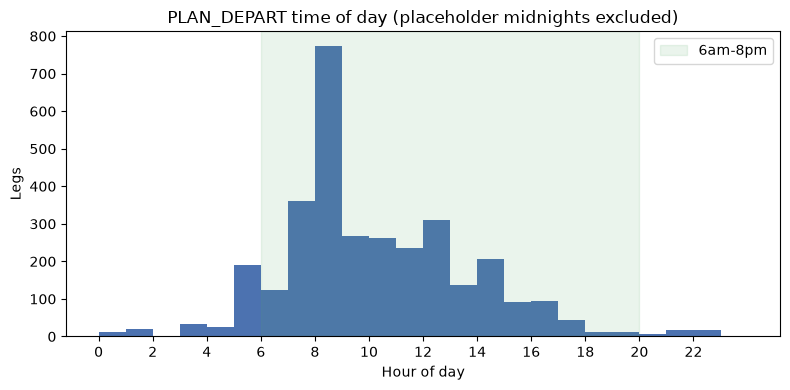

6:00-19:00 window: 89.8% of real departures
5:00-20:00 window: 96.0% of real departures
Busiest single hour: 8:00 with 774 legs


In [49]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(real_depart.dt.hour, bins=24, range=(0, 24), color='#4C72B0')
ax.axvspan(6, 20, color='#55A868', alpha=0.12, label='6am-8pm')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Legs')
ax.set_xticks(range(0, 24, 2))
ax.set_title('PLAN_DEPART time of day (placeholder midnights excluded)')
ax.legend()
plt.tight_layout()
plt.show()

for lo, hi in [(6, 19), (5, 20)]:
    share = ((real_depart.dt.hour >= lo) & (real_depart.dt.hour < hi)).mean()
    print(f'{lo}:00-{hi}:00 window: {share*100:.1f}% of real departures')
busiest = real_depart.dt.hour.value_counts()
print(f'Busiest single hour: {busiest.idxmax()}:00 with {busiest.max()} legs')

**Once the placeholder is removed, departures are overwhelmingly a daytime pattern**: 89.8% fall between 6am and 7pm, 96.0% between 5am and 8pm. The single busiest hour is 8am (774 legs) sitting on top of a broader 7-9am wave — this reads as a fleet dispatching on a morning shift-start, not one spread evenly around the clock.

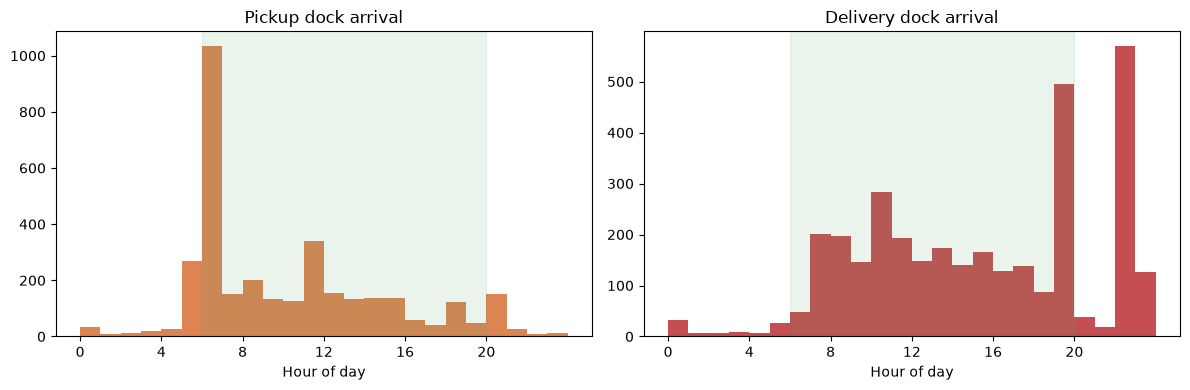

pickup arrival: 83.2% within 6:00-20:00 | busiest hour 6:00 (92% of that hour landed exactly on :00:00 -- a scheduled/appointment stamp, not a GPS ping)
delivery arrival: 75.2% within 6:00-20:00 | busiest hour 22:00 (74% of that hour landed exactly on :00:00 -- a scheduled/appointment stamp, not a GPS ping)


In [50]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, label, color in [(axes[0], 'arrive', 'Pickup dock arrival', '#DD8452'), (axes[1], 'depart', 'Delivery dock arrival', '#C44E52')]:
    vals = dispatch[col].dropna()
    ax.hist(vals.dt.hour, bins=24, range=(0, 24), color=color)
    ax.axvspan(6, 20, color='#55A868', alpha=0.12)
    ax.set_xlabel('Hour of day')
    ax.set_title(label)
    ax.set_xticks(range(0, 24, 4))
plt.tight_layout()
plt.show()

for col, label in [('arrive', 'pickup arrival'), ('depart', 'delivery arrival')]:
    vals = dispatch[col].dropna()
    share = ((vals.dt.hour >= 6) & (vals.dt.hour < 20)).mean()
    spike_hour = vals.dt.hour.value_counts().idxmax()
    at_spike = vals[vals.dt.hour == spike_hour]
    on_the_hour = ((at_spike.dt.minute == 0) & (at_spike.dt.second == 0)).mean()
    print(f'{label}: {share*100:.1f}% within 6:00-20:00 | busiest hour {spike_hour}:00 '
          f'({on_the_hour*100:.0f}% of that hour landed exactly on :00:00 -- a scheduled/appointment stamp, not a GPS ping)')

Dock-arrival timestamps corroborate the same story, with their own artifact worth flagging: pickup arrivals are 83.2% within 6am-8pm, though the single busiest hour (6am, 1,035 legs) is ~92% landed exactly on `06:00:00` — a scheduled dock-open appointment time, not a live GPS ping. Delivery arrivals are 75.2% within 6am-8pm, with secondary exact-on-the-hour spikes at 19:00/19:30 and 22:00/22:30 (same appointment-style logging) pulling a chunk of the mass into the evening rather than truly overnight. None of this changes the shape of the finding — it just means the system logs scheduled dock times rather than continuous telemetry, so the real underlying curve is smoother than the histogram's spikes suggest.

In [51]:
first_idx = dispatch.groupby('TRIP_NUMBER')['LS_LEG_SEQ'].idxmin()
last_idx = dispatch.groupby('TRIP_NUMBER')['LS_LEG_SEQ'].idxmax()
trip_time = dispatch.loc[first_idx, ['TRIP_NUMBER', 'plan_depart_dt']].rename(columns={'plan_depart_dt': 'start_dt'})
trip_time = trip_time.merge(dispatch.loc[last_idx, ['TRIP_NUMBER', 'depart']].rename(columns={'depart': 'end_dt'}), on='TRIP_NUMBER')
trip_time = trip_time.merge(tl_agg[['TRIP_NUMBER', 'ACTUAL_DELIVERY']], on='TRIP_NUMBER', how='left')
trip_time['end_dt'] = trip_time['end_dt'].fillna(trip_time['ACTUAL_DELIVERY'])
trip_time = trip_time.dropna(subset=['start_dt', 'end_dt'])
trip_time['duration_h'] = (trip_time['end_dt'] - trip_time['start_dt']).dt.total_seconds() / 3600
trip_time = trip_time[trip_time['duration_h'] >= 0]

print(f'Trips with a usable start and end timestamp: {len(trip_time)} of {dispatch["TRIP_NUMBER"].nunique()}')
print(f'Median trip length: {trip_time["duration_h"].median():.1f}h')
print(f'Start and end on the same calendar day: {(trip_time["start_dt"].dt.date == trip_time["end_dt"].dt.date).mean()*100:.1f}%')
print(f'Finishes within a single ~14h shift: {(trip_time["duration_h"] <= 14).mean()*100:.1f}%')
print(f'Finishes within 24h: {(trip_time["duration_h"] <= 24).mean()*100:.1f}%')

Trips with a usable start and end timestamp: 1287 of 1326


Median trip length: 4.0h
Start and end on the same calendar day: 89.0%
Finishes within a single ~14h shift: 72.6%
Finishes within 24h: 91.0%


**Answer: yes, this reads as a day-shift fleet, and end-of-day batch matching is well supported.** Departures cluster in the morning (7-9am, peaking at 8am), and 90-96% of all driving activity sits inside a 6am-8pm business day. The trip-level view closes the loop: 89% of trips start and finish within the same calendar day (median trip length 4h), 91% finish within 24h. Most trucks aren't out overnight and don't stay in motion for days — they run a shift and become available for a new load again together, in a predictable evening window. That means a return-load matcher doesn't need to re-optimize continuously through the day: running it once at end-of-shift (with a light morning pass to sweep up the Section-9-style long-tail trips still out from the day before) would catch the large majority of the fleet. The residual ~10-20% outside that window — multi-day trips, and the legs above landing after 8pm — is a minority tail, not a reason to keep the matcher running continuously.